In [35]:
%load_ext autoreload
%autoreload 2

import src.SHAP_like_graph_tool as gp
import src.SHAP_like_graph_tool.utils as gput

import networkx as nx
import html
import io
import json
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import os
import random
from re import X
import numpy as np
import pandas as pd
import networkx as nx
import itertools
from math import factorial
from networkx.algorithms.community import louvain_communities
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.metrics import normalized_mutual_info_score, adjusted_mutual_info_score, mutual_info_score
from sklearn.model_selection import KFold, train_test_split
from sklearn.feature_selection import mutual_info_regression
from node2vec import Node2Vec
from infomap import Infomap
import graph_tool.all as gt
import joblib
from pathlib import Path
from sklearn.model_selection import KFold, train_test_split
from xgboost import XGBClassifier
import optuna
from scipy import stats
from scipy.stats import entropy

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1 - Performance Analysis of artificial graphs - With different subsets of features

In [3]:
def load_json(path):
    with open(path, 'r', encoding='utf-8') as f:
        data = json.load(f)
        G = nx.node_link_graph(data)
    
    print(f"Graphe chargé : {G.number_of_nodes()} nœuds et {G.number_of_edges()} liens.")
    return G

def load_graphml_safe(path):
        with open(path, 'r', encoding='utf-8') as f:
            raw_data = f.read()

        clean_data = html.unescape(raw_data)
        G = nx.read_graphml(io.StringIO(clean_data))
        
        print(f"✅ Graphe chargé : {G.number_of_nodes()} nœuds et {G.number_of_edges()} liens.")
        return G

def add_ground_truth_groups(df, G):
    true_partition = dict(nx.get_node_attributes(G, 'block'))
    
    if not true_partition:
        print("Dictionnaire vide ! Vérifie si 'block' existe dans G.nodes(data=True)")
        return df

    df['group_u'] = df['u'].map(true_partition)
    df['group_v'] = df['v'].map(true_partition)
    
    df['group_u'] = df['group_u'].fillna(-1).astype(int)
    df['group_v'] = df['group_v'].fillna(-1).astype(int)
    df['same_group'] = (df['group_u'] == df['group_v']).astype(int)
    
    return df

def shuffle_ground_truth(df):
    """
    Crée des versions mélangées des colonnes de groupes.
    """
    df_shuffled = df.copy()
    # On récupère tous les IDs uniques présents et on les mélange
    unique_groups = df_shuffled['group_u'].unique()
    shuffled_map = dict(zip(unique_groups, np.random.permutation(unique_groups)))
    
    # On applique le mapping pour que la structure logique "same_group" disparaisse
    df_shuffled['group_u_shuffled'] = df_shuffled['group_u'].map(shuffled_map)
    df_shuffled['group_v_shuffled'] = df_shuffled['group_v'].map(shuffled_map)
    # On recalcule un same_group qui ne veut plus rien dire
    df_shuffled['same_group_shuffled'] = (df_shuffled['group_u_shuffled'] == df_shuffled['group_v_shuffled']).astype(int)
    
    return df_shuffled

def k_fold_cross_validation_exp(G_train, folds_data, features_list=None, n_trials=50, graph_name="G_NAME"):
    study = gput._run_optuna_tuning(folds_data, features_list, n_trials=n_trials)
    
    results = []
    for trial in study.trials:
        if trial.state == optuna.trial.TrialState.COMPLETE:
            results.append({
                'Trial': trial.number,
                'Avg_AUC': trial.value,
                'Std_AUC': trial.user_attrs.get('std_auc'),
                'Avg_AP': trial.user_attrs.get('avg_ap'),
                'Delta_AUC': trial.user_attrs.get('delta_auc'),
                'Params': trial.params
            })
    
    summary_df = pd.DataFrame(results).sort_values(by='Avg_AUC', ascending=False)

    print("\n" + "="*80)
    print(f"{'RÉSULTATS OPTUNA : BASELINE VS TOP CONFIGURATIONS':^80}")
    print("="*80)

    cols = ['Trial', 'Avg_AUC', 'Std_AUC', 'Avg_AP', 'Delta_AUC']
    print(summary_df[summary_df['Trial'] == 0][cols].to_string(index=False))
    print("-" * 80)
    print(summary_df.head(10)[cols].to_string(index=False))
    print("="*80)

    save_dir = "outputs/results"
    os.makedirs(save_dir, exist_ok=True)
    filename = f"optuna_results_{graph_name}.csv"
    full_path = os.path.join(save_dir, filename)
    summary_df.to_csv(full_path, index=False)
    print(f"Résultats sauvegardés dans : {full_path}")

    best_params = study.best_params.copy()
    best_params.update({'tree_method': 'hist', 'n_estimators': 150})
    
    return best_params, summary_df

### 1.1 Execution des expériences

In [24]:
features_GT_proba = ['GT_proba']
features_GT_sbm = ['GT_sbm_density', 'GT_degrees_sbm_u', 'GT_degrees_sbm_v']
features_GT_pos = ['GT_pos_dist', 'GT_spatial_deg_product', 
                   #'GT_spatial_gravity_log', 'GT_degrees_spatial_u','GT_degrees_spatial_v'
                  ]
features_structure = ['pr_u', 'pr_v','ppr_u', 'ppr_v', 'lcc_u', 'lcc_v', 'and_u', 'and_v', 'dc_u', 'dc_v', 'katz_u', 'katz_v',
                              'sp', 'jc', 'aa', 'cn','pa', 'ra']
features_commu_inferee = ['louvain_density', 'same_louvain', 'infomap_density', 'same_infomap', 'sbm_density', 'same_sbm',
                            'leiden_density', 'same_leiden', "surprise_density", "same_surprise", 
                            "significance_density", "same_significance"]
features_embeddings = ["deepwalk_cos", "deepwalk_rank", "deepwalk_had_mean",  "deepwalk_had_std", "deepwalk_dist",
                        "n2v_homophily_cos", "n2v_homophily_rank", "n2v_homophily_had_mean",  "n2v_homophily_had_std", "n2v_homophily_dist",
                      "crosswalk_cos", "crosswalk_rank", "crosswalk_had_mean",  "crosswalk_had_std", "crosswalk_dist"]
features_embeddings_reduced = ['deepwalk_cos', 'deepwalk_dist', 'deepwalk_rank']
features_commu_inferee_reduced = ["surprise_density", "sbm_density", "significance_density"]
features_commu_inferee_normal = ["leiden_density", "louvain_density"]
features_commu_inferee_spatial_based_manual = ["spatial_leiden_density", "spatial_louvain_density"]
features_commu_inferee_spatial_based_scgravity = ["spatial_leiden_scgravity_density", "spatial_louvain_scgravity_density"]
features_commu_inferee_spatial_based_wrdb = ["spatial_leiden_wrdb_density", "spatial_louvain_wrdb_density"]

features_structure_reduced = ['ra', 'pr_u', 'pr_v', 'lcc_u', 'lcc_v', 'katz_u', 'katz_v']


experiments = {
    #"GT_absolue (proba)": features_GT_proba,
    #"GT_sbm": features_GT_sbm,
    #"GT_pos": features_GT_pos,
    #"GT": features_GT_sbm + features_GT_pos,
    #"Inferred_Commu only": features_commu_inferee,
    #"Inferred_Commu spatial based": features_commu_inferee_spatial_based,
    #"Inferred_Commu_reduced": features_commu_inferee_reduced,
    "Inferred_Commu_normal": features_commu_inferee_normal,
    "Inferred_Commu_spatial_manuel": features_commu_inferee_spatial_based_manual,
    "Inferred_Commu_spatial_scgravity": features_commu_inferee_spatial_based_scgravity,
    "Inferred_Commu_spatial_wrdb": features_commu_inferee_spatial_based_wrdb,
    #"Structure_Only": features_structure,
    #"Structure_reduced" : features_structure_reduced,
    #"Embeddings_Only": features_embeddings,
    #"Embeddings_reduced": features_embeddings_reduced,
    "GT_pos": features_GT_pos,
    "GT_pos + Inferred_Commu normal": features_GT_pos + features_commu_inferee_normal,
    "GT_pos + Inferred_Commu spatial manuel": features_GT_pos + features_commu_inferee_spatial_based_manual,
    "GT_pos + Inferred_Commu spatial scgravity": features_GT_pos + features_commu_inferee_spatial_based_scgravity,
    "GT_pos + Inferred_Commu spatial wrdb": features_GT_pos + features_commu_inferee_spatial_based_wrdb,
    #"Structure + Inferred_Commu": features_structure + features_commu_inferee,
    #"Structure + Embeddings": features_structure + features_embeddings,
    #"Full_features_reduced" : features_structure_reduced + features_commu_inferee_reduced + features_embeddings_reduced,
    #"Full_features": features_structure + features_commu_inferee + features_embeddings,
    #"Full_features_spatial_inferees": features_structure + features_commu_inferee_spatial_based + features_embeddings  
}

all_results = []

#for i in [0.00,1.00]:
for i in np.arange(1.00, -0.10, -0.10):
    sbm_val = f"{i:.2f}"
    pos_val = f"{1-i:.2f}"
    G_name = f"artificial_graph_sbmv5_{sbm_val.replace('.', '_')}_pos_{pos_val.replace('.', '_')}"
    G_name_obj = f"artificial_graph_sbmv5_{sbm_val.replace('.', '_')}_pos_{pos_val.replace('.', '_')}"
    
    # 1. Chargement des données d'entraînement
    G_train, dataset_train, dataset_eval, _, _, _ = gp.load_all_data_for_graph(G_name)
    G = load_graphml_safe(f"graph_library/{G_name_obj}.graphml")

    if 'GroundTruth_JSON' in G.graph:
        print(f"[INIT] Extraction de la GT GroundTruth pour {G_name}...")
        gt_raw = json.loads(G.graph['GroundTruth_JSON'])
        
        GT = {'GT_sbm_matrix': np.array(gt_raw['GT_sbm_matrix']),
            'GT_pos': np.array(gt_raw['GT_pos']),
            'GT_sbm_id': np.array(gt_raw['GT_sbm_id']),
            'GT_degrees_sbm': np.array(gt_raw['GT_degrees_sbm']),
            'GT_degrees_spatial': np.array(gt_raw['GT_degrees_spatial'])
             }
        
        if 'P_matrix_JSON' in G.graph:
            print("P_matrix trouvée.")
            GT['GT_proba'] = np.array(json.loads(G.graph['P_matrix_JSON']))
    else:
        print("[WARNING] Aucune GroundTruth_JSON trouvée dans G.graph")
        GT = None

    pre_calculated_folds = gput._prepare_precalculated_folds(G_train, k=1, GroundTruth=GT)
    
    # 3. Lancement des tests
    for exp_name, feat_list in experiments.items():
        missing = set(feat_list) - set(dataset_train.columns)
        if missing:
            print(f" Exp {exp_name} : colonnes manquantes {missing}. Skip.")
            print(set(dataset_train.columns))
            continue

        print(f" Running: {exp_name} for SBM={i}")
        Params, summary_optim = k_fold_cross_validation_exp(G_train, pre_calculated_folds, feat_list, n_trials=10)
        
        stats_df, model, X_test, _, y_test, _ = gp.train_and_test_xgboost(dataset_train, features=feat_list,
                                                                          parameters = Params, plot=False)

        importances = model.feature_importances_
        feat_imp_series = pd.Series(importances, index=feat_list).sort_values(ascending=False)
        print(f"Top 5 Feature Importance pour {exp_name} :")
        print(feat_imp_series.head(5).to_string())

        probs = model.predict_proba(X_test)[:, 1]
        preds = model.predict(X_test)

        if exp_name == "GT_sbm":
            model_GT, X_test_GT_only, y_test_GT_only, probs_GT, preds_GT_only = model, X_test, y_test, probs, preds
        elif exp_name == "Inferred_Commu only":
            model_s, X_test_s, y_test_s, probs_s, preds_s = model, X_test, y_test, probs, preds
            
        # Évaluation sur le dataset de référence FIXE (Graphe SBM 1.0)
        # On force l'ordre des colonnes de eval_dataset pour correspondre au modèle
        X_eval_fixed = dataset_eval[feat_list] 
        stats_eval_df = gp.get_performance_metrics(model, X_eval_fixed, dataset_eval["target"], "EXP_")
        
        all_results.append({
            "Ratio_SBM": i,
            "Experiment": exp_name,
            "AP_train": stats_df["Test_AP"].iloc[0],
            "AUC-ROC_train": stats_df["Test_AUC-ROC"].iloc[0],
            "AP_eval": stats_eval_df["EXP_AP"].iloc[0],
            "AUC-ROC_eval": stats_eval_df["EXP_AUC-ROC"].iloc[0],
            "Top_Feature": feat_imp_series.index[0], # On stocke la #1 pour analyse
            "Top_Importance": feat_imp_series.iloc[0]
        })

# Recap final
df_compare = pd.DataFrame(all_results)

print("\n" + "="*50)
print("RÉCAPITULATIF DES EXPÉRIENCES (SBM vs Ground Truth)")
print("="*50)

# On affiche sans l'index pour plus de clarté si tu as déjà une colonne 'exp_name'
print(df_compare.to_string(index=False, float_format=lambda x: "{:,.4f}".format(x)))

print("="*50 + "\n")

output_dir = "outputs/results"
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, "comparaison_finale_structure_shuffled_v5_normal_VS_spatial_20260421.csv")
df_compare.to_csv(output_path, index=False)
print(f" Succès ! Fichier sauvegardé dans : {output_path}")

SHAP Analysis introuvable pour artificial_graph_sbmv5_1_00_pos_0_00.
✅ Graphe chargé : 198 nœuds et 2609 liens.
[INIT] Extraction de la GT GroundTruth pour artificial_graph_sbmv5_1_00_pos_0_00...
P_matrix trouvée.
[K-FOLD] Préparation séquentielle de 1 folds...
--- Démarrage Parallèle Fold 1 ---
Graphe original: 1596 liens
Graphe d'entraînement: 1356 liens
Liens cachés pour le test: 240

--- Enrichissement du Graphe avec les Métriques de Structure ---
Calcul : PageRank, Clustering, Average Neighbor Degree, Degree Centrality, Katz

--- Enrichissement du Graphe avec les Embeddings ---
Calcul des embeddings via n2v_homophily...
Calcul de Node2Vec (p=2, q=0.5)...
Génération des marches aléatoires (dim=64)...


Generating walks (CPU: 11): 100%|██████████| 9/9 [00:00<00:00, 21.43it/s]


Entraînement du modèle Skip-gram...
Skip-gram terminé en 3.04s
Calcul des embeddings via deepwalk...
Calcul de Node2Vec (p=1, q=1)...
Génération des marches aléatoires (dim=64)...


Generating walks (CPU: 10): 100%|██████████| 9/9 [00:00<00:00, 23.95it/s]


Entraînement du modèle Skip-gram...
Skip-gram terminé en 3.39s
Calcul des embeddings via crosswalk...
Calcul de Node2Vec (p=1, q=1)...
Génération des marches aléatoires (dim=64)...


...

Entraînement du modèle Skip-gram...
Skip-gram terminé en 3.26s
Calcul des embeddings via deepwalk...
Calcul de Node2Vec (p=1, q=1)...
Génération des marches aléatoires (dim=64)...


Generating walks (CPU: 11): 100%|██████████| 9/9 [00:00<00:00, 21.22it/s]


Entraînement du modèle Skip-gram...
Skip-gram terminé en 3.41s
Calcul des embeddings via crosswalk...
Calcul de Node2Vec (p=1, q=1)...
Génération des marches aléatoires (dim=64)...


Generating walks (CPU: 11): 100%|██████████| 9/9 [00:00<00:00, 17.84it/s]


Entraînement du modèle Skip-gram...
Skip-gram terminé en 3.15s

--- Enrichissement du Graphe avec les Communautés ---
Calcul des communautés via louvain...
Calcul des communautés via infomap...
Calcul des communautés via sbm...
Calcul des communautés via leiden...
Calcul des communautés via surprise...
Calcul des communautés via significance...
Calcul des communautés via spatial_leiden...
min_weight final: 2.33e-05 |  nb iter = 4
Null Model inféré normalisé par un facteur de 0.9449578802491254
--- ANALYSE DE L'ASYMÉTRIE ---
Somme de la valeur absolue des différences (|B_avant - B_après|) : 5.82e-14
Écart maximal ponctuel : 4.44e-16
Calcul des communautés via spatial_louvain...
Iteration 0: MAE = 5.231009, Beta = 1.9090
Modèle gravitaire inféré, avec une MAE de 0.009284464183011938, alpha moy = -0.3384 et beta = 7.677661335096883
Vérification : Null Model donne P.sum / 2*nb_edges = 0.9999999996577904
--- ANALYSE DE L'ASYMÉTRIE ---
Somme de la valeur absolue des différences (|B_avant - B

### 1.2 Plot des performances des expériences en fonction de SBM_ratio

--- Infos Dataset ---
Taille (Lignes, Colonnes) : (1100, 9)
Colonnes présentes : ['Ratio_SBM', 'Iter', 'Experiment', 'AP_train', 'AUC-ROC_train', 'AP_eval', 'AUC-ROC_eval', 'Top_Feature', 'Top_Importance']
--------------------


/tmp/ipykernel_271/2007008393.py:134: FutureWarning: The provided callable <function mean at 0x7f8acc9a7f40> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  df_avg = df_compare.groupby(["Ratio_SBM", "Experiment"])[metrics].agg([
/tmp/ipykernel_271/2007008393.py:134: FutureWarning: The provided callable <function mean at 0x7f8acc9a7f40> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  df_avg = df_compare.groupby(["Ratio_SBM", "Experiment"])[metrics].agg([


--- Aperçu après calcul des moyennes (par itération) ---
   Ratio_SBM                                    Experiment  AP_train_mean  \
0        0.0                                      Deepwalk       0.271485   
1        0.0              Deepwalk + Inferred_Commu normal       0.301198   
2        0.0  Deepwalk + Inferred_Commu spatial manuel reg       0.269316   
3        0.0        Deepwalk + Inferred_Commu spatial wrdb       0.304423   
4        0.0                                      GT_proba       0.403712   
5        0.0                         Inferred_Commu_normal       0.202205   
6        0.0            Inferred_Commu_spatial_manuel_iter       0.092364   
7        0.0             Inferred_Commu_spatial_manuel_reg       0.090069   
8        0.0              Inferred_Commu_spatial_scgravity       0.174409   
9        0.0                   Inferred_Commu_spatial_wrdb       0.197620   

   AP_train_ci99  AUC-ROC_train_mean  AUC-ROC_train_ci99  AP_eval_mean  \
0       0.056010     

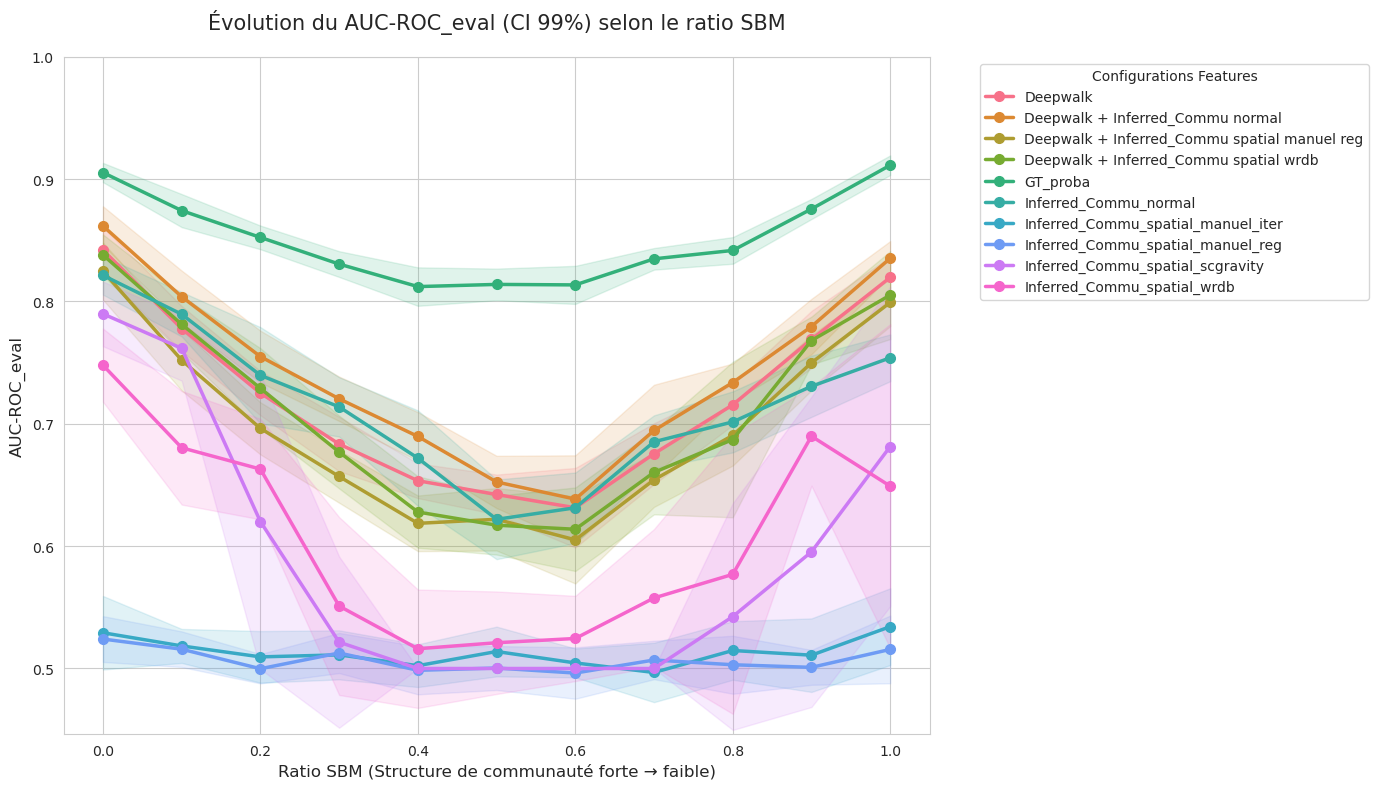

In [12]:
def plot_f1_comparison(df_results, metric="AUC-ROC_eval", name="OUBLI"):
    plt.figure(figsize=(14, 8)) # Un peu plus large pour la légende
    sns.set_style("whitegrid")
    
    # On récupère la liste des expériences uniques
    experiments = df_results['Experiment'].unique()
    # Palette de couleurs cohérente
    palette = sns.color_palette("husl", len(experiments))
    
    for i, exp in enumerate(experiments):
        subset = df_results[df_results["Experiment"] == exp]
        
        # Extraction des noms de colonnes (basé sur ton agrégation précédente)
        mean_col = f"{metric}_mean"
        ci_col = f"{metric}_ci99" # ou ci95 selon le calcul
        
        color = palette[i]
        
        # 1. Tracer la ligne principale
        plt.plot(subset["Ratio_SBM"], subset[mean_col], 
                 marker='o', label=exp, color=color, linewidth=2.5, markersize=7)
        
        # 2. LA LIGNE MAGIQUE : L'intervalle de confiance ombré
        plt.fill_between(
            subset["Ratio_SBM"], 
            subset[mean_col] - subset[ci_col], 
            subset[mean_col] + subset[ci_col], 
            color=color, 
            alpha=0.15 # Transparence de la zone ombrée
        )
    
    # Personnalisation
    plt.title(f"Évolution du {metric} (CI 99%) selon le ratio SBM", fontsize=15, pad=20)
    plt.xlabel("Ratio SBM (Structure de communauté forte → faible)", fontsize=12)
    plt.ylabel(f"{metric}", fontsize=12)
    
    plt.legend(title="Configurations Features", bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # Ajustement dynamique des limites Y
    y_min = df_results[f"{metric}_mean"].min() - 0.05
    plt.ylim(max(0, y_min), 1.0) 
    
    plt.tight_layout()
    
    # Sauvegarde
    output_dir = os.path.join("outputs", "plots")
    os.makedirs(output_dir, exist_ok=True)
    save_path = os.path.join(output_dir, f"{name}_{metric}_CI99_SBM_ratio.png")
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    print(f"Graphique sauvegardé avec IC 99% ici : {save_path}")
    plt.show()

def plot_f1_comparison_old(df_results, metric="F1-Score", name ="OUBLI"):
    plt.figure(figsize=(12, 7))
    sns.set_style("whitegrid")
    
    # Création du lineplot
    # On utilise 'Experiment' pour différencier les lignes par couleur et style
    ax = sns.lineplot(
        data=df_results, 
        x="Ratio_SBM", 
        y= metric, 
        hue="Experiment", 
        style="Experiment", 
        markers=True, 
        dashes=False,
        linewidth=2.5,
        markersize=8
    )
    
    # Personnalisation des axes
    plt.title(f"Évolution du {metric} selon le ratio SBM vs POS", fontsize=15, pad=20)
    plt.xlabel("Ratio SBM (Structure de communauté forte → faible)", fontsize=12)
    plt.ylabel(f"{metric} (Link Prediction)", fontsize=12)
    
    # Inversion de l'axe X si tu veux montrer la difficulté croissante
    # plt.gca().invert_xaxis() 
    
    plt.legend(title="Configurations Features", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.ylim(0.50, 0.95) # Pour bien voir l'échelle de 0 à 1
    
    plt.tight_layout()

    output_dir = os.path.join("outputs", "plots")
    os.makedirs(output_dir, exist_ok=True)
    save_path = os.path.join(output_dir, f"{name}_{metric}_per_SBM_ratio.png")
    
    # 3. La ligne magique
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    print(f"Graphique sauvegardé ici : {save_path}")
    
    plt.show()

def confidence_interval_99(data):
    n = len(data)
    if n < 2: return 0  # Impossible de calculer un IC sur une seule valeur
    mean = np.mean(data)
    sem = stats.sem(data) # Erreur standard : s / sqrt(n)
    # Calcul de l'intervalle avec la loi de Student
    h = sem * stats.t.ppf((1 + 0.99) / 2., n - 1)
    return h

df_compare = pd.read_csv("outputs/results/comparaison_perfs_commus_artificial_graph_sbmv4_10iter_Test_deepwalk.csv")
feat_to_plot = ["Inferred_Commu_normal","Inferred_Commu_spatial_manuel_iter", "Inferred_Commu_spatial_manuel_reg",
                "Inferred_Commu_spatial_scgravity","Inferred_Commu_spatial_wrdb",
                "GT_pos", "GT_proba",
                #"GT_pos + Inferred_Commu normal",
                #"GT_pos + Inferred_Commu spatial manuel iter",
                #"GT_pos + Inferred_Commu spatial manuel reg",
                #"GT_pos + Inferred_Commu spatial scgravity",
                #"GT_pos + Inferred_Commu spatial wrdb",
        #"Deepwalk",
        #"Deepwalk + Inferred_Commu normal",
        #"Deepwalk + Inferred_Commu spatial manuel iter",
        #"Deepwalk + Inferred_Commu spatial manuel reg",
        #"Deepwalk + Inferred_Commu spatial scgravity",
        #"Deepwalk + Inferred_Commu spatial wrdb",
            
]
df_compare = df_compare[df_compare["Experiment"].isin(feat_to_plot)]
df_compare = df_compare.sort_values(by="Experiment", ascending=True)

print(f"--- Infos Dataset ---")
print(f"Taille (Lignes, Colonnes) : {df_compare.shape}")
print(f"Colonnes présentes : {df_compare.columns.tolist()}")
print("-" * 20)

# 3. Agrégation
# On groupe par Ratio_SBM et Experiment pour calculer moyenne et IC
metrics = ["AP_train", "AUC-ROC_train", "AP_eval", "AUC-ROC_eval"] 

df_avg = df_compare.groupby(["Ratio_SBM", "Experiment"])[metrics].agg([
    ('mean', np.mean),
    ('ci99', confidence_interval_99)
]).reset_index()
df_avg.columns = [f"{col[0]}_{col[1]}" if col[1] else col[0] for col in df_avg.columns.values]

# 4. Affichage du résultat agrégé
print("--- Aperçu après calcul des moyennes (par itération) ---")
print(df_avg.head(10))

plot_f1_comparison(df_avg, metric="AUC-ROC_eval", name = "artificial_graphs_shuffled_v4_embed_10iter_normal_VS_spatial_20260428" )

### 1.3 Analyse détaillée des faux positifs, vrais pos, etc ...

In [ ]:
df_same_block = dataset[dataset['same_block_reel'] == 1]

# On compare le taux de liens réels (target) selon les voisins communs
results = df_same_block.groupby(df_same_block['cn'] > 0)['target'].mean()

print("Taux de liens réels (p) au sein d'un bloc :")
print(f"Sans voisins communs : {results[False]:.4f}")
print(f"Avec voisins communs : {results[True]:.4f}")

df_same_block_eval = eval_dataset[eval_dataset['same_block_reel'] == 1]
results_eval = df_same_block_eval.groupby(df_same_block_eval['cn'] > 0)['target'].mean()

print("--- ANALYSE DE LA PLUS-VALUE TOPOLOGIQUE (EVAL) ---")
print(f"Probabilité théorique injectée (p) : ~0.75")
print(f"Taux réel quand CN = 0 : {results_eval.get(False, 0):.4f}")
print(f"Taux réel quand CN > 0 : {results_eval.get(True, 0):.4f}")


sp_results = df_same_block.groupby('sp')['target'].agg(['mean', 'count'])

print("--- ANALYSE DE LA PLUS-VALUE DU SHORTEST PATH (EVAL) ---")
print(f"Probabilité théorique injectée (p) : ~0.75")
print(sp_results)

sp_zero = df_same_block[df_same_block_eval['sp'] == 0]['target'].mean()
sp_exists = df_same_block_eval[df_same_block_eval['sp'] > 0]['target'].mean()

print(f"\nTaux réel quand SP = 0 (aucun chemin) : {sp_zero:.4f}")
print(f"Taux réel quand SP > 0 (chemin existe) : {sp_exists:.4f}")

import pandas as pd
import numpy as np

def analyze_model_deep_dive(X_test, y_test, y_pred, name):
    """
    Analyse consolidée : Matrice de confusion, Communautés et Shortest Path (SP=1).
    """
    # 0. Alignement et préparation
    target = y_test.values if hasattr(y_test, 'values') else y_test
    df_res = pd.DataFrame({
        'target': target,
        'pred': y_pred,
        'same_block': X_test['same_block_reel'].values
    }, index=X_test.index)
    
    # Gestion du SP
    has_sp_col = 'sp' in X_test.columns
    if has_sp_col:
        df_res['sp1'] = (X_test['sp'] == 1).values
    
    total = len(df_res)
    
    # 1. Définition des masques de la matrice de confusion
    tp_m = (df_res['target'] == 1) & (df_res['pred'] == 1)
    fp_m = (df_res['target'] == 0) & (df_res['pred'] == 1)
    fn_m = (df_res['target'] == 1) & (df_res['pred'] == 0)
    tn_m = (df_res['target'] == 0) & (df_res['pred'] == 0)

    # 2. Fonctions utilitaires pour le détail Intra/Inter/SP1
    def get_details(mask):
        count = mask.sum()
        if count == 0: return "0", 0, 0, 0
        intra = (mask & (df_res['same_block'] == 1)).sum()
        inter = (mask & (df_res['same_block'] == 0)).sum()
        sp1 = (mask & df_res['sp1']).sum() if has_sp_col else 0
        return count, intra, inter, sp1

    tp, tp_intra, tp_inter, tp_sp1 = get_details(tp_m)
    fp, fp_intra, fp_inter, fp_sp1 = get_details(fp_m)
    fn, fn_intra, fn_inter, fn_sp1 = get_details(fn_m)
    tn, tn_intra, tn_inter, tn_sp1 = get_details(tn_m)

    # Affichage
    print(f"\n" + "="*60)
    print(f" DEEP DIVE PERFORMANCE : {name} ".center(60, "="))
    print(f"Nombre total de paires : {total}")
    print("-" * 60)

    # SECTION VRAIS POSITIFS
    print(f"VRAIS POSITIFS (TP) : {tp}")
    if tp > 0:
        print(f"  ├─ Intra-bloc : {tp_intra} | Inter-bloc : {tp_inter}")
        if has_sp_col:
            print(f"  └─ Dont déjà connus (SP=1) : {tp_sp1} ({tp_sp1/tp:.1%})")
            print(f"  └─ Trouvés par intelligence (SP!=1) : {tp - tp_sp1}")

    print("-" * 60)

    # SECTION FAUX POSITIFS
    print(f"FAUX POSITIFS (FP) : {fp}")
    if fp > 0:
        print(f"  ├─ Intra-bloc : {fp_intra} (Confusion même bloc)")
        print(f"  ├─ Inter-bloc : {fp_inter} (Erreur sur lien rare)")
        if has_sp_col:
            print(f"  └─ Dont avec SP=1 : {fp_sp1}")

    print("-" * 60)

    # SECTION FAUX NÉGATIFS
    print(f"FAUX NÉGATIFS (FN) : {fn}")
    if fn > 0:
        print(f"  ├─ Intra-bloc : {fn_intra} | Inter-bloc : {fn_inter}")
        if has_sp_col:
            print(f"  └─ Dont connus ratés (SP=1) : {fn_sp1}")

    print("-" * 60)

    # SECTION VRAIS NÉGATIFS
    print(f"VRAIS NÉGATIFS (TN) : {tn}")
    print(f"  └─ Intra-bloc : {tn_intra} | Inter-bloc : {tn_inter}")

    print("-" * 60)

    # SYNTHÈSE SUR L'INCONNU (Intelligence réelle)
    if has_sp_col:
        hidden_links_mask = (df_res['target'] == 1) & (~df_res['sp1'])
        n_hidden = hidden_links_mask.sum()
        if n_hidden > 0:
            tp_hidden = (tp_m & ~df_res['sp1']).sum()
            print(f"SCORE SUR LIENS MASQUÉS (SP!=1) : {tp_hidden}/{n_hidden} ({tp_hidden/n_hidden:.2%})")
            
    # DENSITÉS DE CONTRÔLE
    n_intra_total = (df_res['same_block'] == 1).sum()
    n_inter_total = (df_res['same_block'] == 0).sum()
    print(f"Densités observées : p={ (tp_intra+fn_intra)/n_intra_total:.4f} | q={ (tp_inter+fn_inter)/n_inter_total:.4f}")
    print("="*60)

# Utilisation :
# analyze_predictions_vs_sp1(X_test_s, y_test, preds)


X_test_GT_only = X_test_GT_only.copy()
X_test_GT_only['sp'] = dataset.loc[X_test_GT_only.index, 'sp']
analyze_model_deep_dive(X_test_GT_only, y_test_GT_only, preds_GT_only, "GT Only")

X_test_s = X_test_s.copy()
X_test_s['sp'] = dataset.loc[X_test_s.index, 'sp']
X_test_s['same_block_reel'] = dataset.loc[X_test_s.index, 'same_block_reel']
analyze_model_deep_dive(X_test_s, y_test_s, preds_s, "Structure Only")

### 1.4 plots des AP curves

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

def plot_ap_comparison(models_dict, X_eval_dict, y_true_dict):
    """
    Trace les courbes Precision-Recall en filtrant dynamiquement les colonnes
    pour éviter les erreurs de mismatch XGBoost.
    """
    plt.figure(figsize=(10, 7))
    
    for name, model in models_dict.items():
        trained_features = model.feature_names_in_
        X_filtered = X_eval_dict[name][trained_features]
        
        probs = model.predict_proba(X_filtered)[:, 1]
        
        precision, recall, _ = precision_recall_curve(y_true_dict[name], probs)
        ap = average_precision_score(y_true_dict[name], probs)
        
        plt.plot(recall, precision, label=f'{name} (AP = {ap:.4f})')
    
    plt.xlabel('Recall (Rappel)')
    plt.ylabel('Precision (Précision)')
    plt.title('Comparaison des courbes Precision-Recall')
    plt.legend()
    plt.grid(True)
    plt.show()

# Appel de la fonction
plot_ap_comparison(
     {'GroundTruth': model_GT, 'Structure': model_s},
     {'GroundTruth': X_test_GT_only, 'Structure': X_test_s},
     {'GroundTruth': y_test_GT_only, 'Structure': y_test_s}
)

### 1.5 Analyse de variance de probas prédites

In [ ]:
def compare_score_distributions(model_gt, X_gt, model_struct, X_struct):
    """
    Compare la variance et la finesse des scores de probabilité entre GT et Structure.
    """
    # 1. Récupération des probabilités (classe 1)
    trained_features_gt = model_gt.feature_names_in_
    trained_features_s = model_struct.feature_names_in_
    X_gt = X_gt[trained_features_gt]
    X_struct = X_struct[trained_features_s]

    probs_gt = model_gt.predict_proba(X_gt)[:, 1]
    probs_st = model_struct.predict_proba(X_struct)[:, 1]
    
    df_compare = pd.DataFrame({
        'prob_gt': probs_gt,
        'prob_st': probs_st,
        'intra': X_gt['same_block_reel'].values
    })

    results = []
    for label, is_intra in [("Intra-Bloc (Même communauté)", 1), ("Inter-Bloc (Communautés diff.)", 0)]:
        subset = df_compare[df_compare['intra'] == is_intra]
        
        results.append({
            "Type": label,
            "Modèle": "Ground Truth",
            "Variance": subset['prob_gt'].var(),
            "Valeurs Uniques": subset['prob_gt'].nunique(),
            "Moyenne": subset['prob_gt'].mean()
        })
        results.append({
            "Type": label,
            "Modèle": "Structure",
            "Variance": subset['prob_st'].var(),
            "Valeurs Uniques": subset['prob_st'].nunique(),
            "Moyenne": subset['prob_st'].mean()
        })

    # Affichage sous forme de tableau propre
    df_res = pd.DataFrame(results)
    print("\n=== ANALYSE DE LA FINESSE DES SCORES (GT vs STRUCTURE) ===")
    print(df_res.to_string(index=False))
    
    return df_compare

df_ana = compare_score_distributions(model_GT, X_test_GT_only, model_s, X_test_s)

### 1.5 Analyse des communautés inférées

#### 1.5.a Nb commus, denisté, conductance, etc.

In [135]:
def analyze_communities_fromgraph(G):
    nodes_dict = dict(G.nodes(data=True))
    df_comm = pd.DataFrame.from_dict(nodes_dict, orient='index')
    id_cols = [col for col in df_comm.columns if col.endswith('_id')]

    total_volume = sum(dict(G.degree()).values())
    stats = []
    
    print(f"--- Analyse des communautés ({len(G)} nœuds) ---")
    
    for col in id_cols:
        counts = df_comm[col].value_counts()
        n_comm = len(counts)
        mean_size = counts.mean()
        max_size = counts.max()
        min_size = counts.min()
        std_size = counts.std()
        
        # Calcul de l'entropie (pour voir si les tailles sont équilibrées)
        probs = counts / len(G)
        entropy = -np.sum(probs * np.log2(probs))

        # Calcul de la densité & conductance pour chaque communauté
        densities = []
        conductances = []
        comm_mean_degrees = []
        for comm_id in counts.index:
            
            # Calcul densité 
            nodes_in_comm = set(df_comm.index[df_comm[col] == comm_id])
            n = len(nodes_in_comm)
            
            subgraph = G.subgraph(nodes_in_comm)
            actual_edges = subgraph.number_of_edges()
            if n > 1:
                possible_edges = (n * (n - 1)) / 2
                densities.append(actual_edges / possible_edges)
            else:
                densities.append(0.0)

            # Calcul degrés moyens
            degs = [G.degree(node) for node in nodes_in_comm]
            comm_mean_degrees.append(np.mean(degs))
                
            # Calcul conductance
            vol_s = sum(G.degree(node) for node in nodes_in_comm)
            
            # Nombre d'arêtes sortantes (cut)
            cut_s = 0
            for node in nodes_in_comm:
                for neighbor in G.neighbors(node):
                    if neighbor not in nodes_in_comm:
                        cut_s += 1
            
            # Formule de la conductance
            if vol_s > 0 and vol_s < total_volume:
                # On prend le min entre le volume de S et le reste du graphe
                denom = min(vol_s, total_volume - vol_s)
                conductances.append(cut_s / denom)
            else:
                conductances.append(1.0)
                
        all_comm_degs_mean = np.mean(comm_mean_degrees)
        all_comm_degs_std = np.std(comm_mean_degrees)
        coef_variation_degrees = all_comm_degs_std / all_comm_degs_mean if all_comm_degs_mean > 0 else 0

        stats.append({
            'Méthode': col.replace('_id', ''),
            'Nb Commus': n_comm,
            'Taille Moy': round(mean_size, 2),
            'Taille Max': max_size,
            'Taille Min': min_size,
            'Taille Std' : std_size,
            'Entropie': round(entropy, 2),
            'Densité Moy': round(np.mean(densities), 4),
            'Densité Min': round(np.min(densities), 4),
            'Densité Max': round(np.max(densities), 4),
            'Densité Std': round(np.std(densities), 4),
            'Cond. Moy': round(np.mean(conductances), 4), # Plus c'est bas, mieux c'est
            'Cond. Std': round(np.std(conductances), 4),
            'Cond. Max': round(np.max(conductances), 4),
            "Coef Variation degrés" : round(coef_variation_degrees, 4), # Plus c'est bas, mieux c'est
        })
        
    stats_df = pd.DataFrame(stats).sort_values(by='Méthode', ascending=True)
        
    return stats_df, df_comm, id_cols

def plot_community_density_matrix(G, df_comm, community_col):
    """
    Affiche la heatmap des densités de liens inter/intra communautés.
    """
    # Récupération des IDs uniques et triés pour la matrice
    comm_ids = sorted(df_comm[community_col].unique())
    n_comm = len(comm_ids)
    matrix = np.zeros((n_comm, n_comm))
    
    # Mapping direct : Index du DataFrame (ID nœud) -> ID Communauté
    node_to_comm = df_comm[community_col].to_dict()
    
    # Comptage des liens existants
    for u, v in G.edges():
        if u in node_to_comm and v in node_to_comm:
            c1, c2 = node_to_comm[u], node_to_comm[v]
            idx1, idx2 = comm_ids.index(c1), comm_ids.index(c2)
            matrix[idx1, idx2] += 1
            if idx1 != idx2:
                matrix[idx2, idx1] += 1
                
    # Calcul des tailles de chaque communauté
    sizes = [len(df_comm[df_comm[community_col] == c]) for c in comm_ids]
    
    # Normalisation par le nombre de liens théoriques max
    for i in range(n_comm):
        for j in range(n_comm):
            n_i, n_j = sizes[i], sizes[j]
            if i == j: # Densité Intra
                possible = (n_i * (n_i - 1)) / 2 if n_i > 1 else 1
            else: # Densité Inter
                possible = n_i * n_j
            matrix[i, j] = matrix[i, j] / possible

    plt.figure(figsize=(10, 8))
    sns.heatmap(matrix, annot=True, fmt=".4f", cmap="YlGnBu", 
                xticklabels=comm_ids, yticklabels=comm_ids)
    plt.title(f"Matrice de densité inter/intra : {community_col}")
    plt.ylabel("ID Communauté")
    plt.xlabel("ID Communauté")
    plt.show()

def plot_feature_evolution_with_std(df, feature_name, output_path = None):
    """
    Affiche la moyenne (ligne), l'écart-type (pointillés) et les points individuels.
    """
    if feature_name not in df.columns:
        print(f"Erreur : {feature_name} introuvable.")
        return

    plt.figure(figsize=(12, 8))
    
    # On récupère les couleurs par défaut de Seaborn pour que tout concorde
    methods = df['Méthode'].unique()
    colors = sns.color_palette("husl", len(methods))
    
    for i, methode in enumerate(methods):
        subset = df[df['Méthode'] == methode]
        color = colors[i]
        
        # 1. Calcul des stats agrégées par ratio
        stats = subset.groupby('SBM_Ratio')[feature_name].agg(['mean', 'std']).reset_index()
        
        # 2. Plot de tous les points (avec jitter pour éviter les chevauchements parfaits)
        # alpha=0.3 pour ne pas surcharger visuellement
        #sns.scatterplot(data=subset, x='SBM_Ratio', y=feature_name, color=color, alpha=0.3, s=20, label=None)
        
        # 3. Ligne de la Moyenne
        plt.plot(stats['SBM_Ratio'], stats['mean'], color=color, 
                 linewidth=2.5, label=f"Moyenne {methode}")
        
        # 4. Lignes de l'Écart-type (Moyenne +/- STD)
        plt.plot(stats['SBM_Ratio'], stats['mean'] + stats['std'], color=color, 
                 linestyle='--', linewidth=1, alpha=0.7)
        plt.plot(stats['SBM_Ratio'], stats['mean'] - stats['std'], color=color, 
                 linestyle='--', linewidth=1, alpha=0.7)

    plt.title(f"Analyse statistique : {feature_name}", fontsize=14)
    plt.xlabel("Ratio SBM", fontsize=12)
    plt.ylabel(feature_name, fontsize=12)
    plt.grid(True, which='both', linestyle=':', alpha=0.5)
    
    # On gère la légende manuellement pour éviter les doublons
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()

    if output_path is not None : 
        plt.savefig(output_path, bbox_inches='tight', dpi=300)
        print(f"Graphique sauvegardé sous : {output_path}")

    plt.show()

In [136]:
all_results = []

for i_rep in range(1, 11):
    for j in np.arange(0.00, 1.10, 0.10):
        sbm_val = f"{j:.2f}"
        pos_val = f"{1-j:.2f}"
        #G_name = f"artificial_graph_sbmv4_{sbm_val.replace('.', '_')}_pos_{pos_val.replace('.', '_')}"
        G_name = f"artificial_graph_sbmv4_{sbm_val.replace('.', '_')}_pos_{pos_val.replace('.', '_')}_{i_rep}"
        
        # 1. Chargement des données d'entraînement
        #Graph, dataset_train, dataset_eval, _, _, _ = gp.load_all_data_for_graph(G_name)
        Graph = gp.loadsave_data_joblib(data=None, filename=f"G_kept_w_struct_com_dist_{G_name}", mode="load")
        
        df_stats, df_full, id_cols = analyze_communities_fromgraph(Graph)
        df_stats['Rep_ID'] = i_rep
        df_stats['SBM_Ratio'] = j
        #df_stats['Graph_Name'] = G_name
        
        all_results.append(df_stats)

--- Analyse des communautés (198 nœuds) ---
--- Analyse des communautés (198 nœuds) ---
--- Analyse des communautés (198 nœuds) ---
--- Analyse des communautés (198 nœuds) ---
--- Analyse des communautés (198 nœuds) ---
--- Analyse des communautés (198 nœuds) ---
--- Analyse des communautés (198 nœuds) ---
--- Analyse des communautés (198 nœuds) ---
--- Analyse des communautés (198 nœuds) ---
--- Analyse des communautés (198 nœuds) ---
--- Analyse des communautés (198 nœuds) ---
--- Analyse des communautés (198 nœuds) ---
--- Analyse des communautés (198 nœuds) ---
--- Analyse des communautés (198 nœuds) ---
--- Analyse des communautés (198 nœuds) ---
--- Analyse des communautés (198 nœuds) ---
--- Analyse des communautés (198 nœuds) ---
--- Analyse des communautés (198 nœuds) ---
--- Analyse des communautés (198 nœuds) ---
--- Analyse des communautés (198 nœuds) ---
--- Analyse des communautés (198 nœuds) ---
--- Analyse des communautés (198 nœuds) ---
--- Analyse des communautés (198

--- Agrégation terminée ---
   SBM_Ratio  Rep_ID  Méthode  Nb Commus  Taille Moy  Taille Max  Taille Min  \
0        0.0       1  louvain          5        39.6          67           4   

   Taille Std  Entropie  Densité Moy  Densité Min  Densité Max  Densité Std  \
0   30.204304       1.9       0.3956       0.2222       0.6667       0.1556   

   Cond. Moy  Cond. Std  Cond. Max  Coef Variation degrés  
0     0.2246      0.158     0.5349                 0.7231  
Graphique sauvegardé sous : outputs/plots/Cond._Std_graph_sbmv4_GT_pos_30iter_all_ratios.png


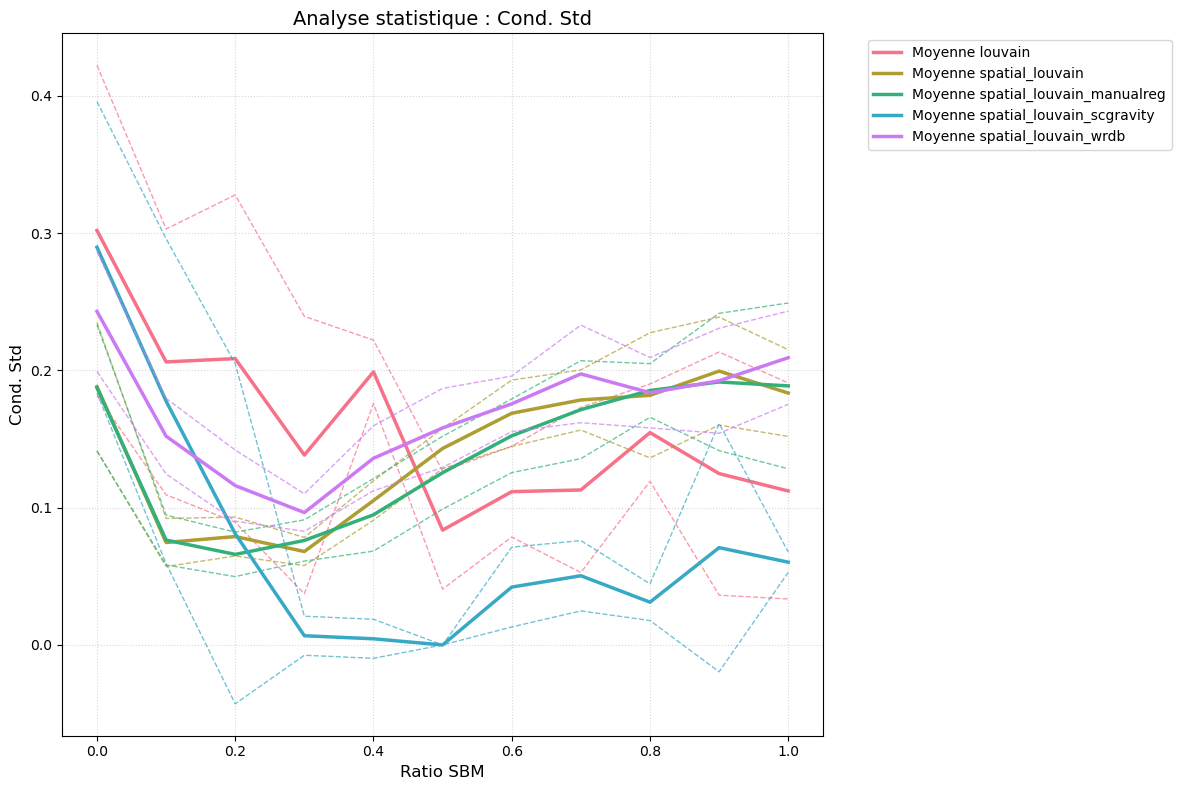

In [144]:
df_final_results = pd.concat(all_results, ignore_index=True)

# Réordonner les colonnes pour avoir les identifiants au début
cols = ['SBM_Ratio', 'Rep_ID', 'Méthode'] + [c for c in df_final_results.columns if c not in ['SBM_Ratio', 'Rep_ID', 'Méthode']]
df_final_results = df_final_results[cols].sort_values(['SBM_Ratio', 'Rep_ID', 'Méthode'])

#Filtre des commus qui nous intéressent : 
comus_to_track = ["louvain",
                "spatial_louvain",
                "spatial_louvain_manualreg",
                "spatial_louvain_wrdb",
                "spatial_louvain_scgravity"
                 ]
df_final_results = df_final_results[df_final_results["Méthode"].isin(comus_to_track)]

print("--- Agrégation terminée ---")
print(df_final_results.head(1))

# "Densité Moy", "Densité Std", "Nb Commus", "Taille Moy", "Taille Std", 'Cond. Moy', 'Cond. Std', "Coef Variation degrés"
metric =   'Cond. Std'
plot_name = f"{metric}_graph_sbmv4_GT_pos_30iter_all_ratios".replace(" ", "_")
output_path = f"outputs/plots/{plot_name}.png"

plot_feature_evolution_with_std(df_final_results, metric, output_path = output_path)

#### 1.5.b Diamètre des communautés

In [ ]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import pdist, squareform

def calculate_spatial_diameter(G, pos_attr, id_cols, df_comm):
    """
    Calcule le diamètre spatial (distance Euclidienne max) pour chaque communauté.
    
    Args:
        G: Le graphe NetworkX
        pos_attr: Nom de l'attribut contenant les positions (ex: 'GT_pos')
        id_cols: Liste des colonnes de communautés (ex: ['louvain_id', 'spatial_louvain_id'])
        df_comm: DataFrame contenant les assignations (index=node_id)
        
    Returns:
        Un dictionnaire de dictionnaires contenant les stats de diamètre par méthode.
    """
    # Extraction des positions dans un dictionnaire pour accès rapide
    pos_dict = {n: np.array(data[pos_attr]) for n, data in G.nodes(data=True)}
    
    diameter_stats = []

    for col in id_cols:
        diameters = []
        # On itère sur chaque communauté unique de la méthode
        for comm_id in df_comm[col].unique():
            nodes_in_comm = df_comm.index[df_comm[col] == comm_id].tolist()
            
            if len(nodes_in_comm) < 2:
                diameters.append(0.0)
                continue
            
            # Extraction des coordonnées pour les nœuds de la communauté
            coords = np.array([pos_dict[n] for n in nodes_in_comm])
            
            # Calcul de toutes les distances par paires (Euclidienne par défaut)
            # pdist est très performant pour cela
            dists = pdist(coords)
            
            # Le diamètre est la distance maximale trouvée
            diameters.append(np.max(dists))
            
        diameter_stats.append({
            'Méthode': col.replace('_id', ''),
            'Diamètre Spatial Moy': round(np.mean(diameters), 4),
            'Diamètre Spatial Max': round(np.max(diameters), 4),
            'Diamètre Spatial Std': round(np.std(diameters), 4)
        })
        
    return pd.DataFrame(diameter_stats)

### 1.6 Exploration visuelle des positions et catégories

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx
import os

def plot_node_spatial_with_edges(G, title="Focus Liaisons Internes", selected_blocks=None):
    """
    Affiche les nœuds et les arêtes internes des blocs sélectionnés.
    """
    pos = nx.get_node_attributes(G, 'pos')
    blocks = nx.get_node_attributes(G, 'block')
    
    if not pos or not blocks:
        print("❌ Erreur : 'pos' ou 'block' manquants.")
        return

    plt.figure(figsize=(10, 10))
    
    # 1. Fond : tous les nœuds en gris
    all_nodes = list(G.nodes())
    nx.draw_networkx_nodes(G, pos, nodelist=all_nodes, node_color='lightgray', 
                           node_size=10, alpha=0.2)

    # 2. Sélection des nœuds et arêtes à mettre en avant
    if selected_blocks:
        target_nodes = [n for n, b in blocks.items() if b in selected_blocks]
        # On ne garde que les arêtes dont les DEUX extrémités sont dans les blocs sélectionnés
        target_edges = [(u, v) for u, v in G.edges() if u in target_nodes and v in target_nodes]
        
        # 3. Dessin des arêtes internes (le signal SBM)
        nx.draw_networkx_edges(G, pos, edgelist=target_edges, edge_color='blue', 
                               width=0.5, alpha=0.4)
        
        # 4. Dessin des nœuds sélectionnés (colorés par bloc)
        node_colors = [blocks[n] for n in target_nodes]
        scatter = nx.draw_networkx_nodes(G, pos, nodelist=target_nodes, 
                                         node_color=node_colors, cmap='tab10', 
                                         node_size=40, edgecolors='black', linewidths=0.5)
        
        if len(selected_blocks) > 1:
            plt.colorbar(scatter, label="ID du Bloc")
    
    plt.title(title)
    plt.axis('off') # On enlève les axes pour mieux voir la structure
    
    # Sauvegarde
    plot_dir = os.path.join(PROJECT_ROOT, "outputs", "plots")
    os.makedirs(plot_dir, exist_ok=True)
    plt.savefig(os.path.join(plot_dir, f"{title.replace(' ', '_')}.png"), dpi=300)
    
    plt.show()

# --- TEST ---
# Essaye avec 2 blocs qui ont des scores F1 élevés
# plot_node_spatial_with_edges(G, selected_blocks=[1, 2], title="Structure Interne Blocs 1 et 2")

In [ ]:
G_name = f"artificial_graph_sbm_1_00_pos_0_00"
dataset, _, _, _ = gp.load_all_data_for_graph(G_name)
G = load_json(f"graph_library/{G_name}.json")
plot_node_spatial_with_edges(G, title="Correlation Spatiale à i=1 (Géo Pur)", selected_blocks=[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20])

### 1.7 Analyse de corrélation entre features et GT

In [46]:
features_GT = ['GT_sbm_density', 'GT_degrees_sbm_u', 'GT_degrees_sbm_v',
               'GT_pos_dist', 'GT_degrees_spatial_u','GT_degrees_spatial_v', 'GT_spatial_deg_product']
features_structure = ['pr_u', 'pr_v','ppr_u', 'ppr_v', 'lcc_u', 'lcc_v', 'and_u', 'and_v', 'dc_u', 'dc_v', 'katz_u', 'katz_v',
                              'sp', 'jc', 'aa', 'cn','pa', 'ra']
features_commu_inferee = ['louvain_density', 
                          #'infomap_density', 'sbm_density','leiden_density',"surprise_density", "significance_density",
                          #'spatial_leiden_density',  
                          'spatial_louvain_density', "spatial_louvain_scgravity_density", 
                          'spatial_louvain_wrdb_density']
features_embeddings = ["deepwalk_cos", "deepwalk_rank", "deepwalk_had_mean",  "deepwalk_had_std",
                        "n2v_homophily_cos", "n2v_homophily_rank", "n2v_homophily_had_mean",  "n2v_homophily_had_std",
                      "crosswalk_cos", "crosswalk_rank", "crosswalk_had_mean",  "crosswalk_had_std"]
all_matrices = {}
results_corr = []

for i in np.arange(0.00, 1.10, 0.10):
    sbm_val = f"{i:.2f}"
    pos_val = f"{1-i:.2f}"
    G_name = f"artificial_graph_sbmv4_{sbm_val.replace('.', '_')}_pos_{pos_val.replace('.', '_')}"
    
    # 1. Chargement des données d'entraînement
    G_train, dataset_train, dataset_eval, _, _, _ = gp.load_all_data_for_graph(G_name)

    #features_to_test = [c for c in dataset_eval.columns if c not in features_GT and c not in ['u', 'v', 'target', 'label']]
    features_to_test = features_commu_inferee
    
    current_corr = dataset_eval[features_to_test + features_GT].corr(method='spearman')
    sub_matrix = current_corr.loc[features_to_test, features_GT]
    all_matrices[i] = sub_matrix

    #print(f"\n--- Matrice de Corrélation GT pour Alpha = {i} ---")
    print(sub_matrix.round(3))

    for f in features_to_test:
        for gt in features_GT:
            results_corr.append({
                'alpha': i,
                'feature': f,
                'gt_feature': gt,
                'correlation': current_corr.loc[f, gt]
            })

df_evolution = pd.DataFrame(results_corr)

SHAP Analysis introuvable pour artificial_graph_sbmv4_0_00_pos_1_00.
                                   GT_sbm_density  GT_degrees_sbm_u  \
louvain_density                             0.039             0.027   
spatial_louvain_density                     0.042             0.023   
spatial_louvain_scgravity_density           0.052             0.081   
spatial_louvain_wrdb_density                0.004             0.064   

                                   GT_degrees_sbm_v  GT_pos_dist  \
louvain_density                               0.017       -0.679   
spatial_louvain_density                       0.026       -0.316   
spatial_louvain_scgravity_density             0.064       -0.748   
spatial_louvain_wrdb_density                  0.064       -0.220   

                                   GT_degrees_spatial_u  GT_degrees_spatial_v  \
louvain_density                                   0.014                -0.007   
spatial_louvain_density                           0.003                -

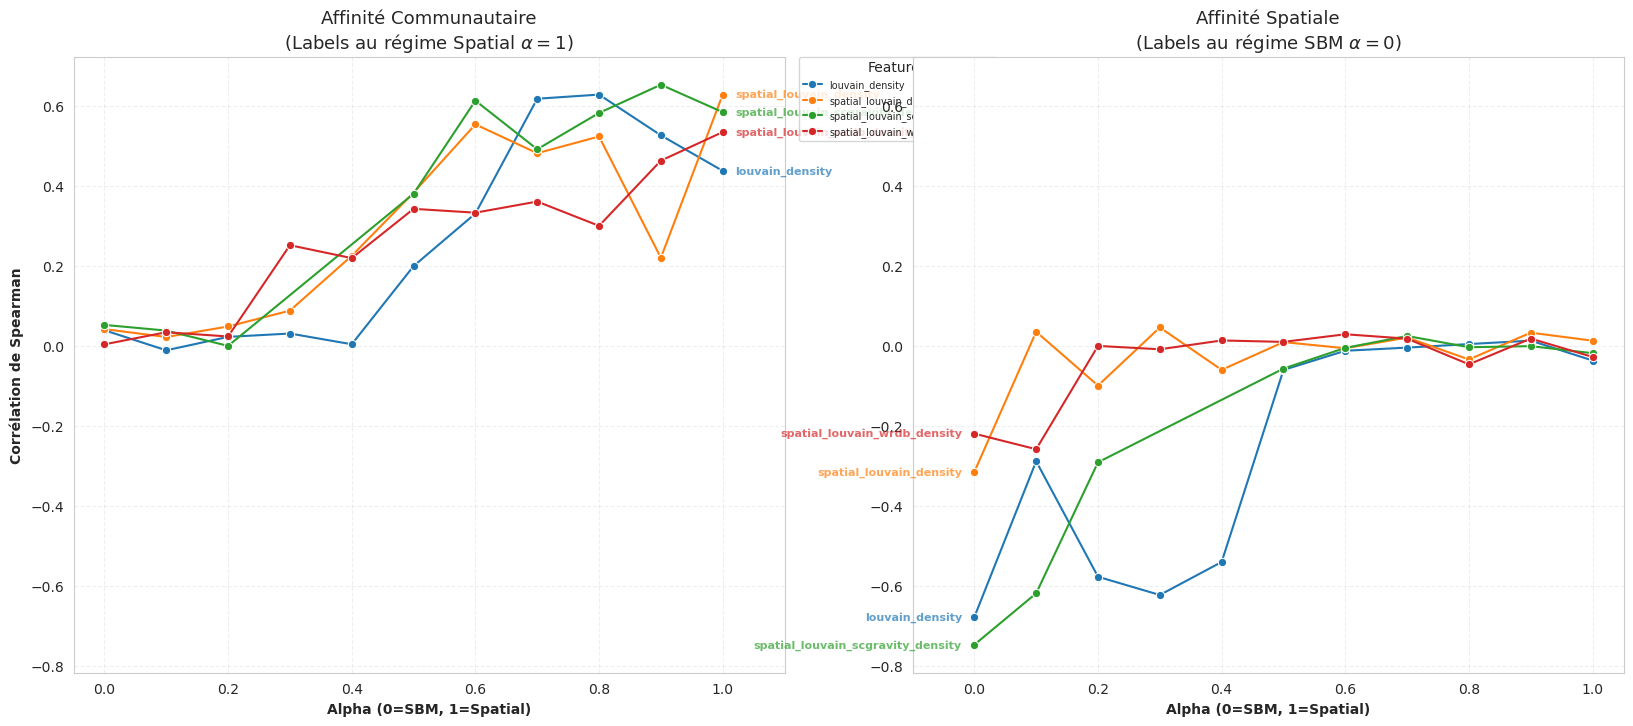

In [16]:
gt_commu = 'GT_sbm_density'
gt_spatial = 'GT_pos_dist'

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8), sharey=True)

def add_labels_inverted(ax, data, hue_col, x_target, alignment='left'):
    lines = ax.get_lines()
    features = data[hue_col].unique()
    for i, feature in enumerate(features):
        subset = data[data[hue_col] == feature]
        idx = (subset['alpha'] - x_target).abs().idxmin()
        point = subset.loc[idx]
        color = lines[i].get_color()
        offset = 0.02 if alignment == 'left' else -0.02
        ax.text(point['alpha'] + offset, point['correlation'], feature, fontsize=8, va='center', ha=alignment, color=color, fontweight='bold', alpha=0.7)

# --- Plot 1 : SBM (Labels à DROITE @ alpha=1.0) ---
data_commu = df_evolution[df_evolution['gt_feature'] == gt_commu]
sns.lineplot(data=data_commu, x='alpha', y='correlation', hue='feature', marker='o', ax=ax1)
ax1.set_title(f"Affinité Communautaire\n(Labels au régime Spatial $\\alpha=1$)", fontsize=13)
add_labels_inverted(ax1, data_commu, 'feature', x_target=1.0, alignment='left')
ax1.set_xlim(-0.05, 1.1) 
ax1.legend(title="Features", bbox_to_anchor=(1.02, 1), loc='upper left', fontsize='x-small', borderaxespad=0.)

# --- Plot 2 : Spatial (Labels à GAUCHE @ alpha=0.0) ---
data_spatial = df_evolution[df_evolution['gt_feature'] == gt_spatial]
sns.lineplot(data=data_spatial, x='alpha', y='correlation', hue='feature', marker='o', ax=ax2, legend=False)
ax2.set_title(f"Affinité Spatiale\n(Labels au régime SBM $\\alpha=0$)", fontsize=13)
add_labels_inverted(ax2, data_spatial, 'feature', x_target=0.0, alignment='right')
ax2.set_xlim(-0.1, 1.05)

for ax in [ax1, ax2]:
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.set_xlabel("Alpha (0=SBM, 1=Spatial)", fontweight='bold')
    ax.set_ylabel("Corrélation de Spearman", fontweight='bold')
    ax2.tick_params(labelleft=True)
    ax2.yaxis.set_major_locator(plt.MultipleLocator(0.2))
    
plt.subplots_adjust(wspace=0.18) 
plt.show()

### 1.8 - Analyse de transférabilité

In [ ]:
features_GT_sbm = ['GT_sbm_density', 'same_GT_sbm']
features_commu_inferee = ['louvain_density', 'same_louvain', 'infomap_density', 'same_infomap', 'sbm_density', 'same_sbm',
                            'leiden_density', 'same_leiden', "surprise_density", "same_surprise", 
                            "significance_density", "same_significance"]
features_commu_surprise = ["surprise_density", "same_surprise"]

experiments = {
    "GT_sbm": features_GT_sbm,
    "Inferred_Commu only": features_commu_inferee,
    "Surprise_mothafucka": features_commu_surprise
 }

trained_models = {} 
all_transfer_results = []

G_source = f"artificial_graph_sbmv4_1_00_pos_0_00"
graphs_tests = ["artificial_graph_sbmv4_bis_1_00_pos_0_00",
                "artificial_graph_sbmv4_ter_1_00_pos_0_00",
                "artificial_graph_sbmv4_quad_1_00_pos_0_00"
               ]

print(f"\n--- PHASE 1 : Entrainement des modèles sur le graphe Source ---")
G_train_src , dataset_train_src, dataset_eval_src, _, _, _ = gp.load_all_data_for_graph(G_source)

pre_calculated_folds = gput._prepare_precalculated_folds(G_train_src, k=1)

for exp_name, feat_list in experiments.items():
    missing = set(feat_list) - set(dataset_train_src.columns)
    if missing:
        print(f" Exp {exp_name} : colonnes manquantes {missing}. Skip.")
        print(set(dataset_train_src.columns))
        continue

    print(f" Running: {exp_name}")
    Params, summary_optim = k_fold_cross_validation_exp(G_train_src, pre_calculated_folds, feat_list, n_trials=30)
    
    stats_df, model, X_test, _, y_test, _ = gp.train_and_test_xgboost(dataset_train_src, features=feat_list,
                                                                      parameters = Params, plot=False)

    X_src = dataset_eval_src[feat_list]
    y_src = dataset_eval_src["target"]

    stats_transfer = gp.get_performance_metrics(model, X_src, y_src, "TRANSFER_")
    importances = model.feature_importances_
    top_feat = feat_list[np.argmax(importances)]

    all_transfer_results.append({
            "Graph_name" : "GRAPH SOURCE",
            "Experiment": exp_name,
            "AUC_Transfer": stats_transfer["TRANSFER_AUC-ROC"].iloc[0],
            "AP_Transfer": stats_transfer["TRANSFER_AP"].iloc[0],
            "Top_Feature": top_feat
        })

    trained_models[exp_name] = {"model": model, "features": feat_list}


print(f"\n--- PHASE 2 : Test de transférabilité sur tous les graphes ---")
for target_graph_name in graphs_tests :
    print(f" Inférence sur : {target_graph_name}")
    try:
        _, _, dataset_eval_target, _, _, _ = gp.load_all_data_for_graph(target_graph_name)
    except:
        print(f" Graphe {target_graph_name} introuvable. Skip.")
        continue

    for exp_name, model_data in trained_models.items():
        model = model_data["model"]
        feat_list = model_data["features"]
        
        if not set(feat_list).issubset(dataset_eval_target.columns):
            continue

        X_target = dataset_eval_target[feat_list]
        y_target = dataset_eval_target["target"]
        
        stats_transfer = gp.get_performance_metrics(model, X_target, y_target, "TRANSFER_")
        
        importances = model.feature_importances_
        top_feat = feat_list[np.argmax(importances)]

        all_transfer_results.append({
            "Graph_name" : target_graph_name,
            "Experiment": exp_name,
            "AUC_Transfer": stats_transfer["TRANSFER_AUC-ROC"].iloc[0],
            "AP_Transfer": stats_transfer["TRANSFER_AP"].iloc[0],
            "Top_Feature": top_feat
        })

# --- RÉCAPITULATIF ET ANALYSE ---
df_transfer = pd.DataFrame(all_transfer_results)
print("\n" + "="*60)
print("RÉSULTATS DE TRANSFÉRABILITÉ (Modèle Source -> Graphes Cibles)")
print("="*60)
pivot_results = df_transfer.pivot(index="Graph_name", columns="Experiment", values="AUC_Transfer")
print(pivot_results.to_string(float_format=lambda x: "{:,.4f}".format(x)))

In [ ]:
plot_f1_comparison(df_transfer, metric="AUC_Transfer")

### 1.9 - NullModels spatiaux inférés, analyse

In [48]:
def plot_null_model_comparison(G1, G2, mode="residuals", p_matrix_name="P_Null_model_ManualIter", title1="Graphe P_pos", title2="Graphe deepwalk"):
    """
    mode="residuals" -> Affiche la distribution de (A - P)
    mode="probabilities" -> Affiche la distribution de P
    """
    def get_analysis_data(G, p_name, mode):
        A = nx.to_numpy_array(G)
        P = G.graph.get(p_name)
        if P is None: return None, None
        
        if mode == "residuals":
            return (A - P).flatten(), "Résidus globaux ($A_{ij} - P_{ij}$)"
        elif mode == "probabilities":
            # Focus uniquement sur les liens existants
            mask = (A == 1)
            return P[mask], "Probabilités $P_{ij}$ (Uniquement sur liens réels)"
        else : 
            print(f"ERREUR : mode non reconnu : {mode}")
            return None

    data1, label = get_analysis_data(G1, p_matrix_name, mode)
    data2, _ = get_analysis_data(G2, p_matrix_name, mode)

    if data1 is None or data2 is None:
        print(f"Erreur : Matrice {p_matrix_name} manquante.")
        return

    fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
    
    # Code couleur différencié pour ne pas s'embrouiller
    c1, c2 = ('#3498db', '#95a5a6') if mode == "residuals" else ('#8e44ad', '#f1c40f')

    sns.histplot(data1, kde=True, ax=axes[0], color=c1)
    axes[0].set_title(f"{title1}\n{p_matrix_name}")
    
    sns.histplot(data2, kde=True, ax=axes[1], color=c2)
    axes[1].set_title(f"{title2}\n{p_matrix_name}")

    for ax in axes:
        ax.set_xlabel(label)
        if mode == "residuals":
            ax.axvline(0, color='black', linestyle='--', alpha=0.5)
        else:
            ax.set_xlim(0, 1) # Les probas sont bornées
            ax.axvline(np.mean(data1), color=c1, linestyle=':', label=f'Moy {title1}')
            ax.axvline(np.mean(data2), color=c2, linestyle=':', label=f'Moy {title2}')
            ax.legend()

    plt.suptitle(f"Enquête Null Model : {label}", fontsize=14, fontweight='bold')
    plt.tight_layout()
    #plt.show()

    print(f"[{mode.upper()}] {title1} -> Moyenne: {np.mean(data1):.4f}, Médiane: {np.median(data1):.4f}, Std: {np.std(data1):.4f}")
    print(f"[{mode.upper()}] {title2} -> Moyenne: {np.mean(data2):.4f}, Médiane: {np.median(data2):.4f}, Std: {np.std(data2):.4f}")

--------- sbm_val 0.00 Iter 1 ---------
[RESIDUALS] Graphe P_pos -> Moyenne: 0.0000, Médiane: -0.0091, Std: 0.2651
[RESIDUALS] Graphe deepwalk -> Moyenne: 0.0000, Médiane: -0.0040, Std: 0.2607
[PROBABILITIES] Graphe P_pos -> Moyenne: 0.4465, Médiane: 0.4696, Std: 0.2204
[PROBABILITIES] Graphe deepwalk -> Moyenne: 0.4677, Médiane: 0.4766, Std: 0.2245
--------- sbm_val 0.10 Iter 1 ---------
[RESIDUALS] Graphe P_pos -> Moyenne: 0.0000, Médiane: -0.0197, Std: 0.2770
[RESIDUALS] Graphe deepwalk -> Moyenne: 0.0001, Médiane: -0.0124, Std: 0.2666
[PROBABILITIES] Graphe P_pos -> Moyenne: 0.3882, Médiane: 0.4122, Std: 0.2080
[PROBABILITIES] Graphe deepwalk -> Moyenne: 0.4430, Médiane: 0.4451, Std: 0.2448
--------- sbm_val 0.20 Iter 1 ---------
[RESIDUALS] Graphe P_pos -> Moyenne: 0.0000, Médiane: -0.0348, Std: 0.2913
[RESIDUALS] Graphe deepwalk -> Moyenne: 0.0000, Médiane: -0.0207, Std: 0.2790
[PROBABILITIES] Graphe P_pos -> Moyenne: 0.3269, Médiane: 0.3385, Std: 0.1927
[PROBABILITIES] Graphe de

/tmp/ipykernel_271/371726594.py:28: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)


[RESIDUALS] Graphe P_pos -> Moyenne: -0.0001, Médiane: -0.0815, Std: 0.3170
[RESIDUALS] Graphe deepwalk -> Moyenne: 0.0000, Médiane: -0.0063, Std: 0.2602
[PROBABILITIES] Graphe P_pos -> Moyenne: 0.2005, Médiane: 0.1812, Std: 0.1206
[PROBABILITIES] Graphe deepwalk -> Moyenne: 0.4712, Médiane: 0.4800, Std: 0.2503


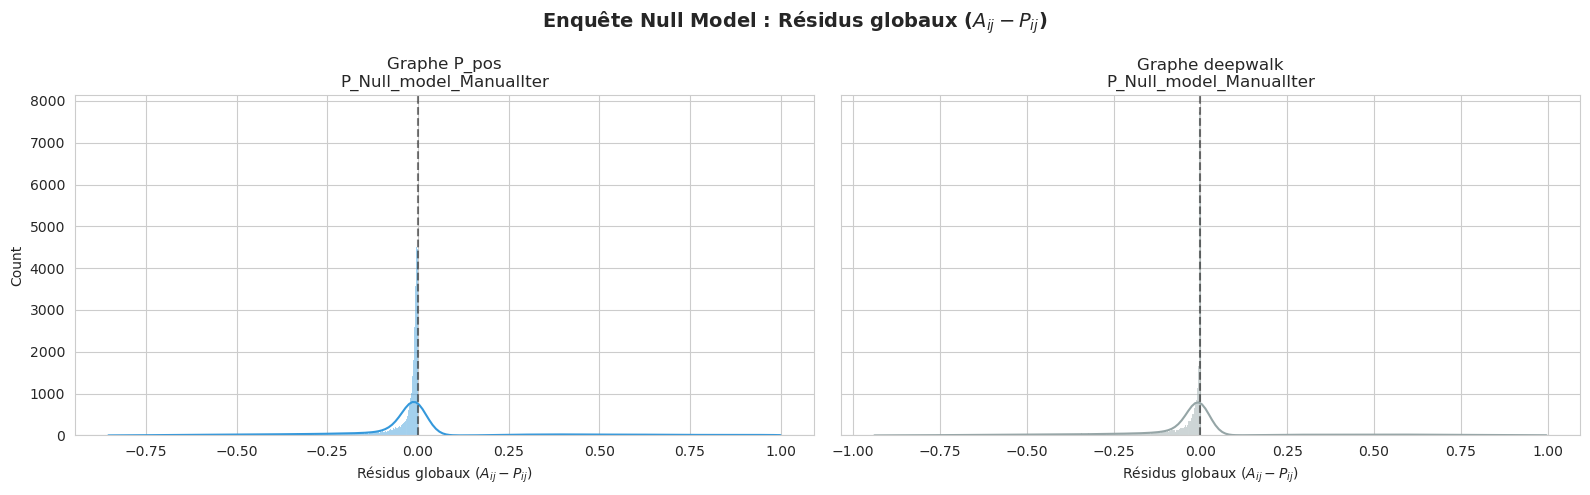

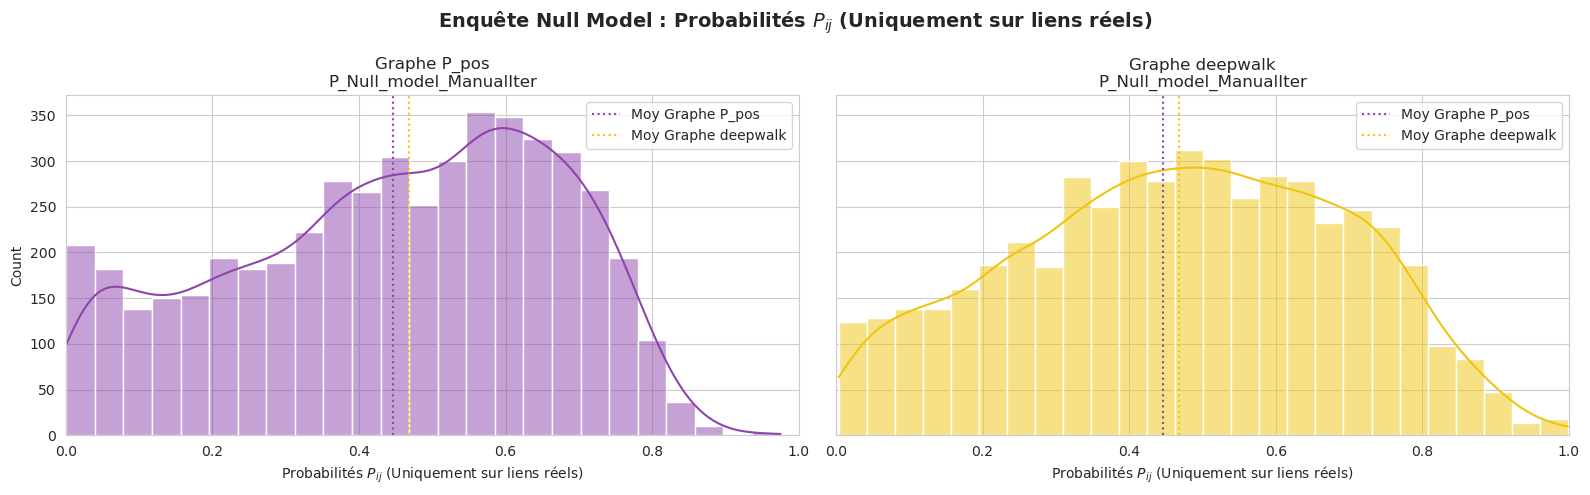

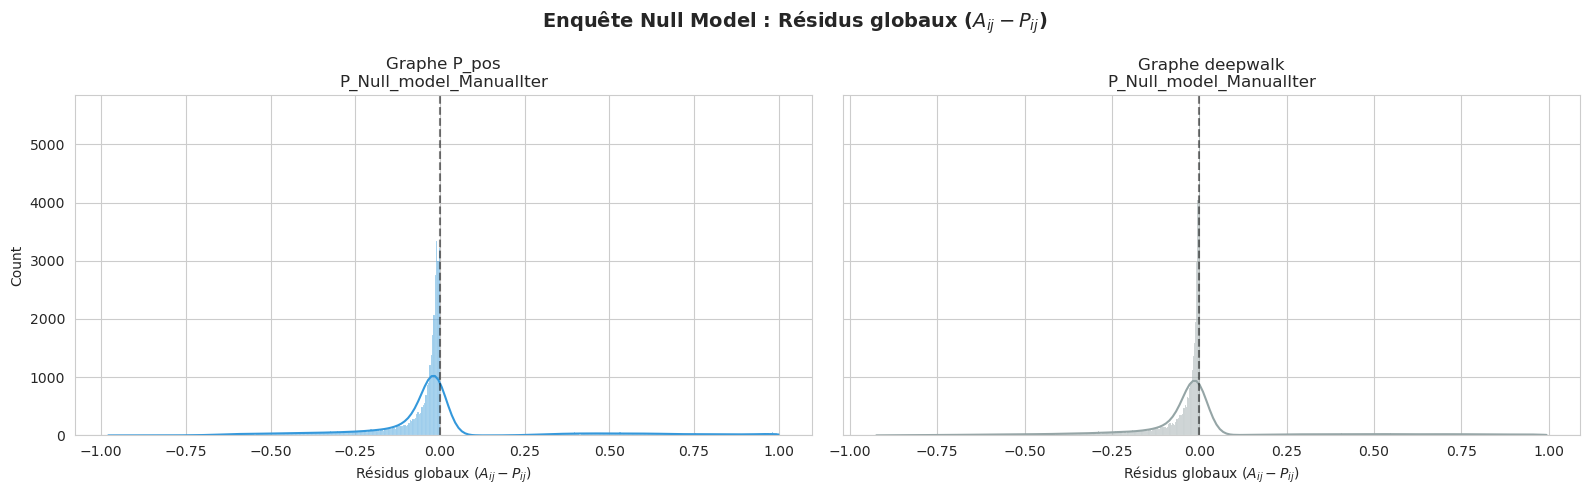

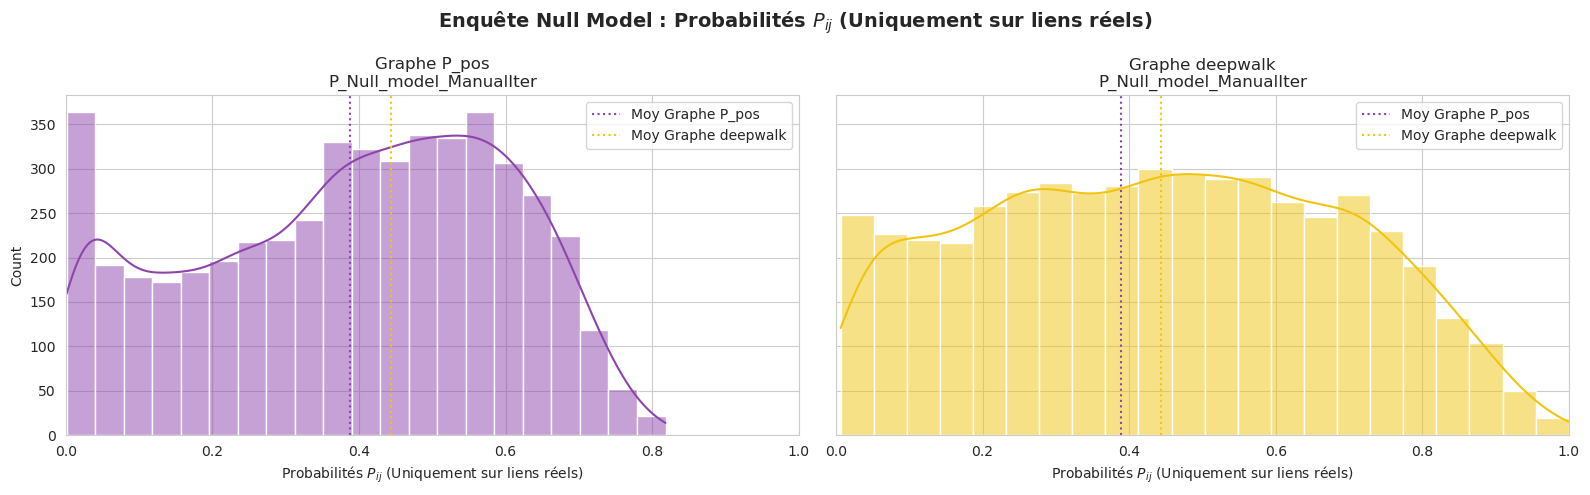

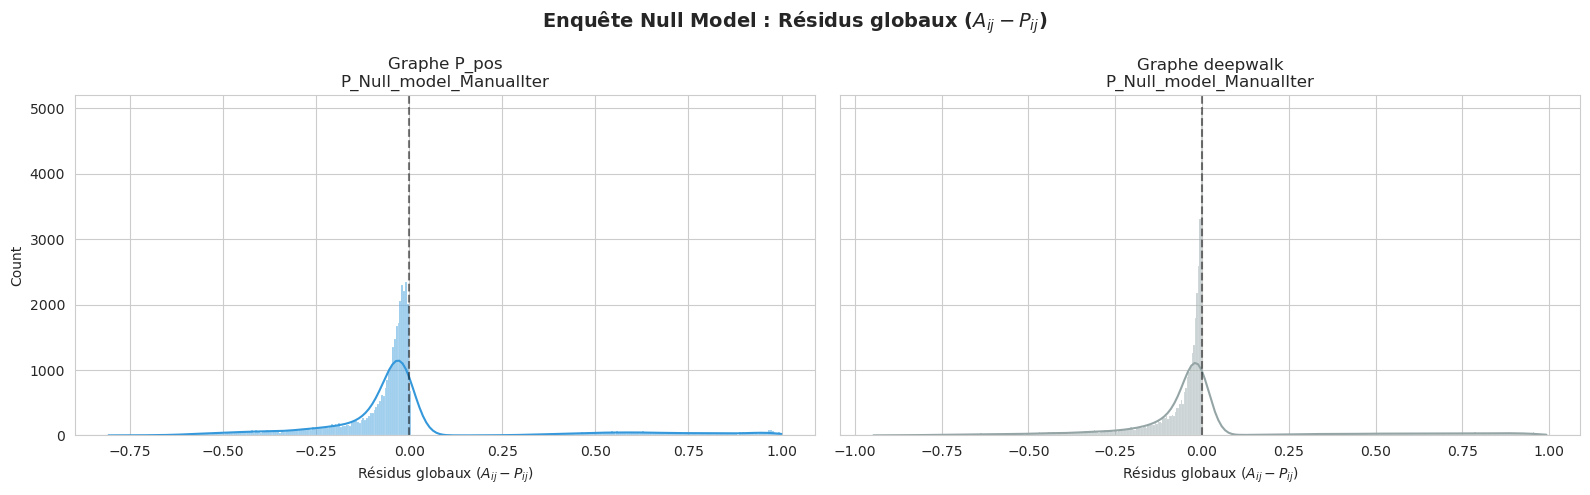

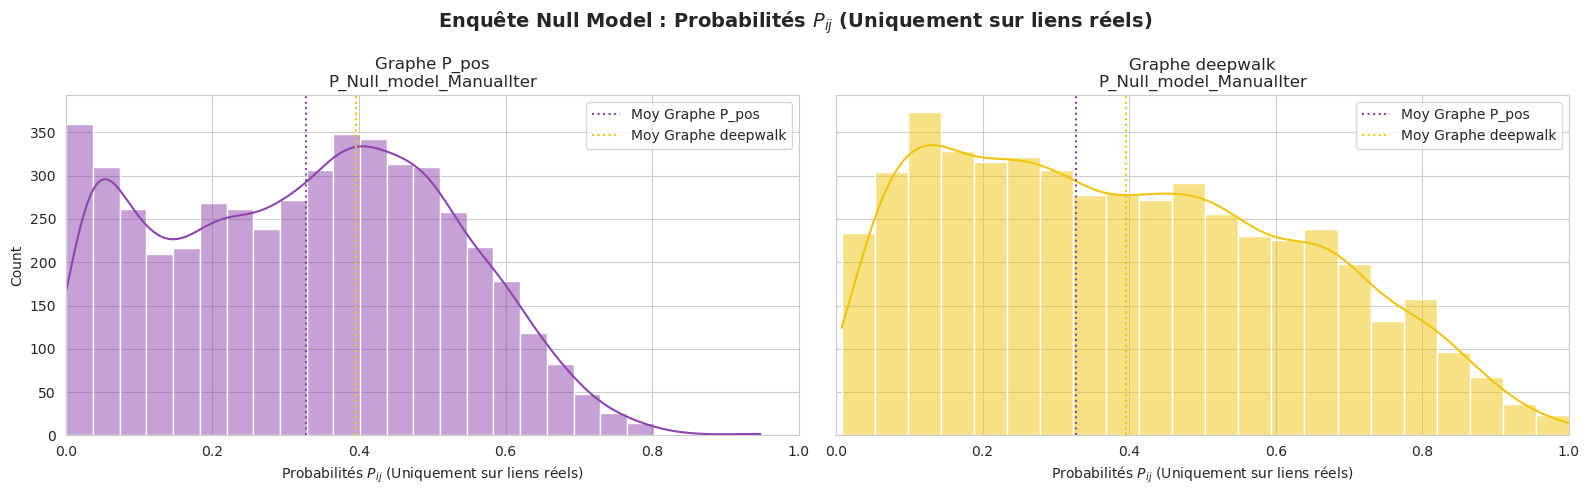

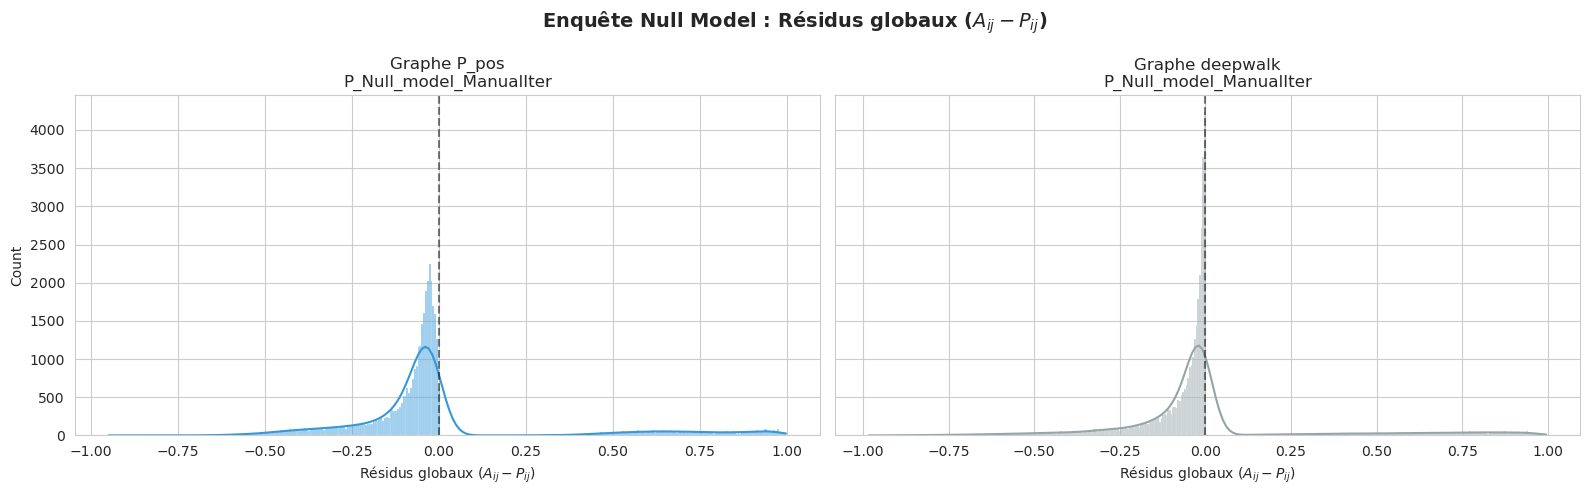

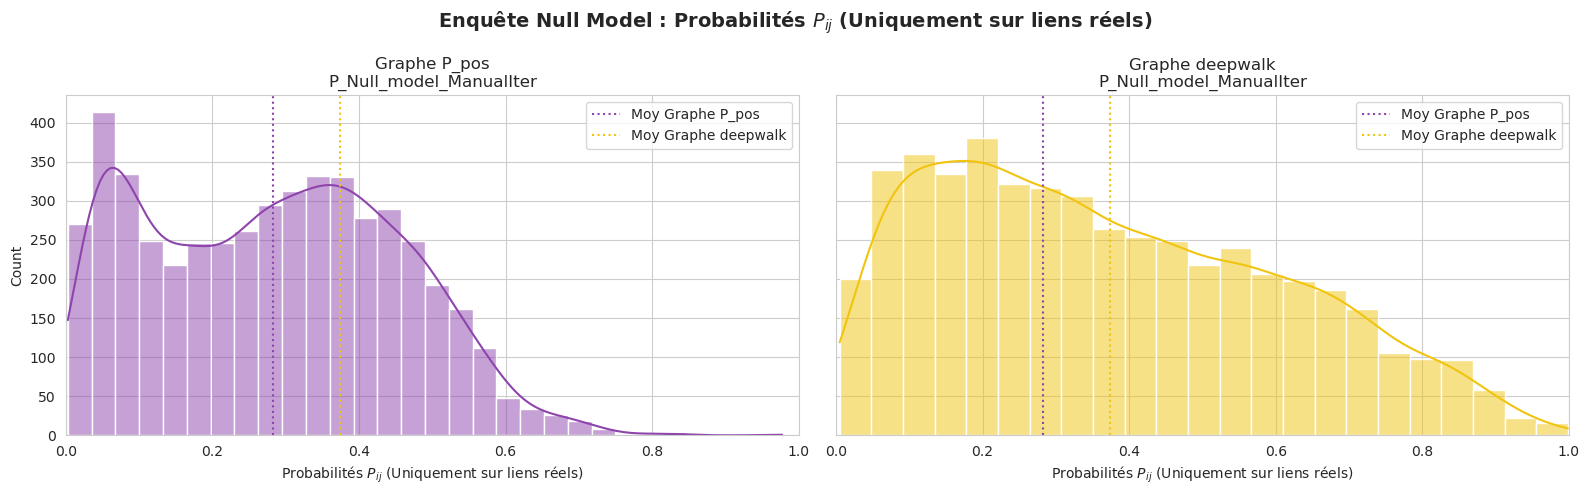

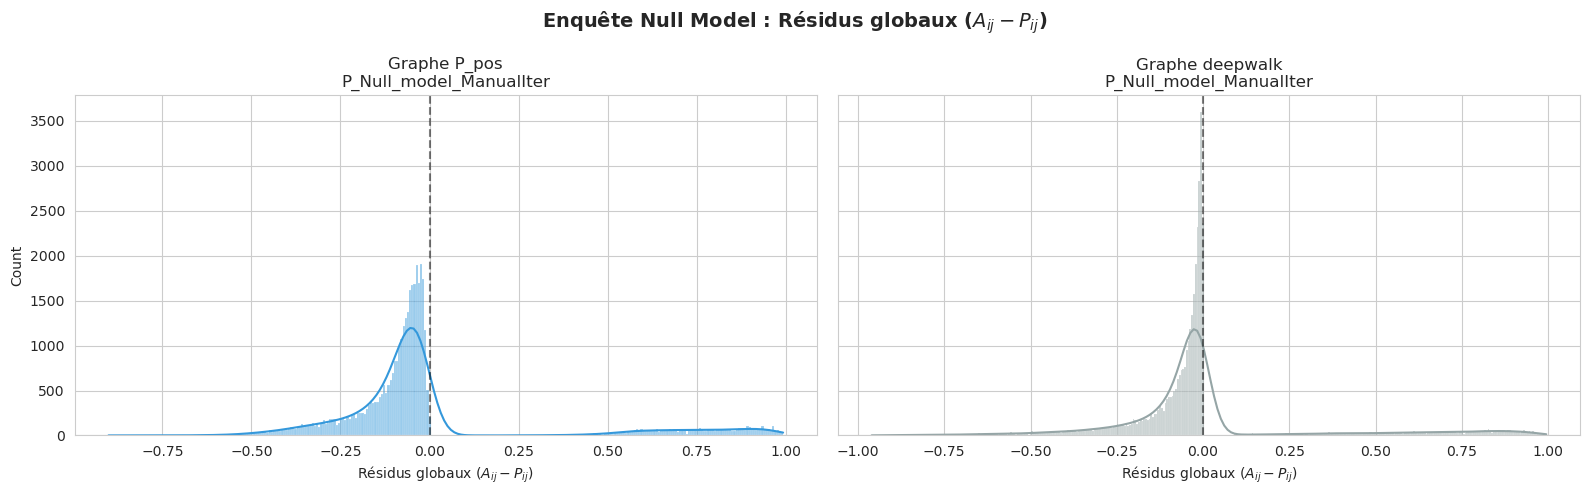

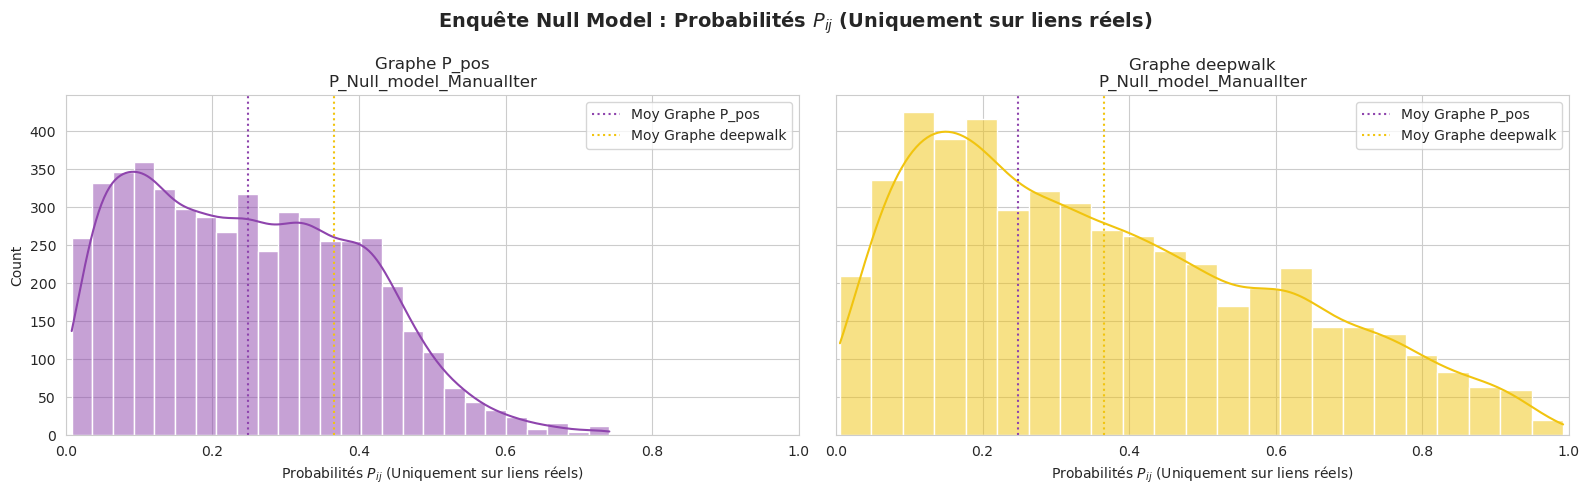

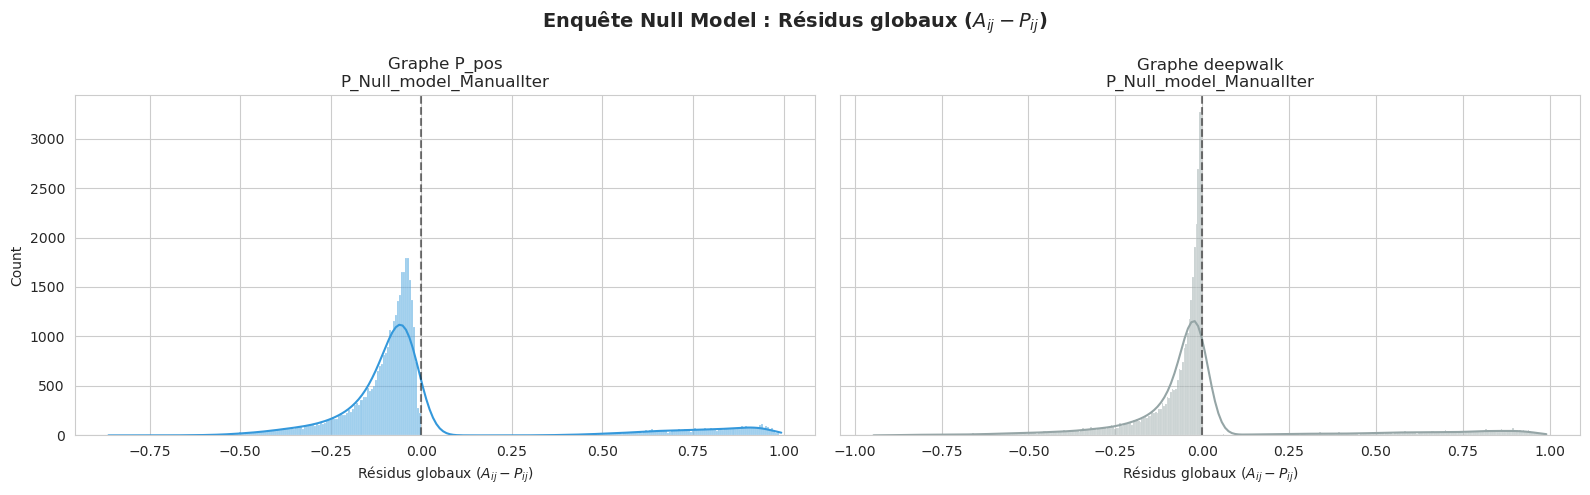

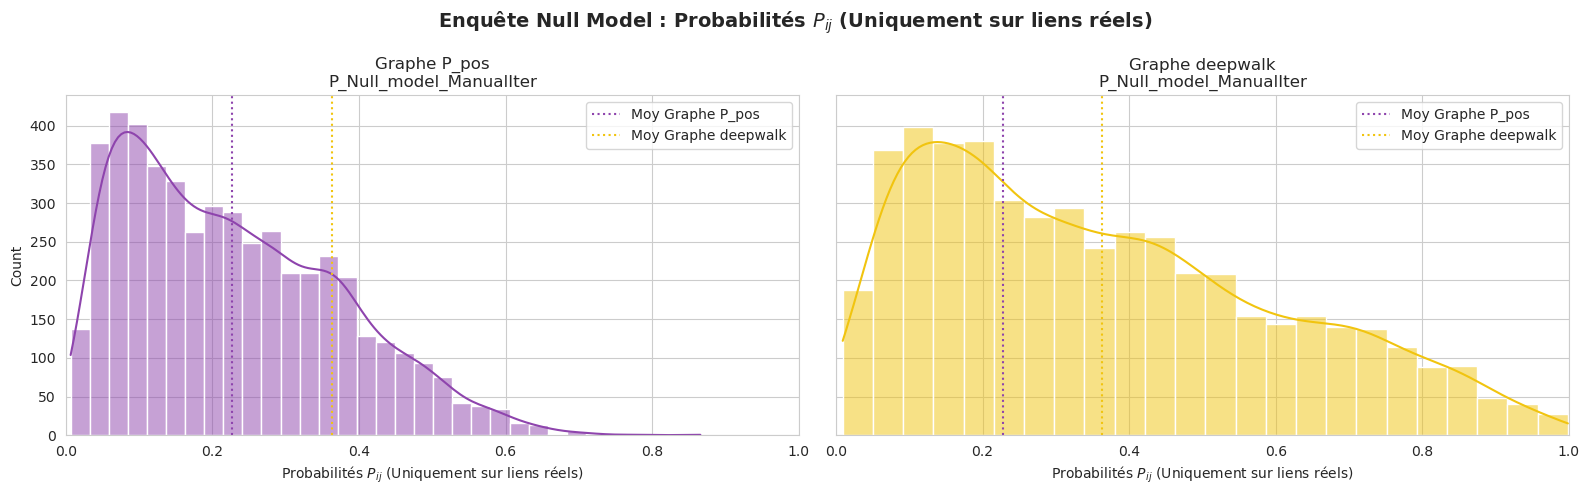

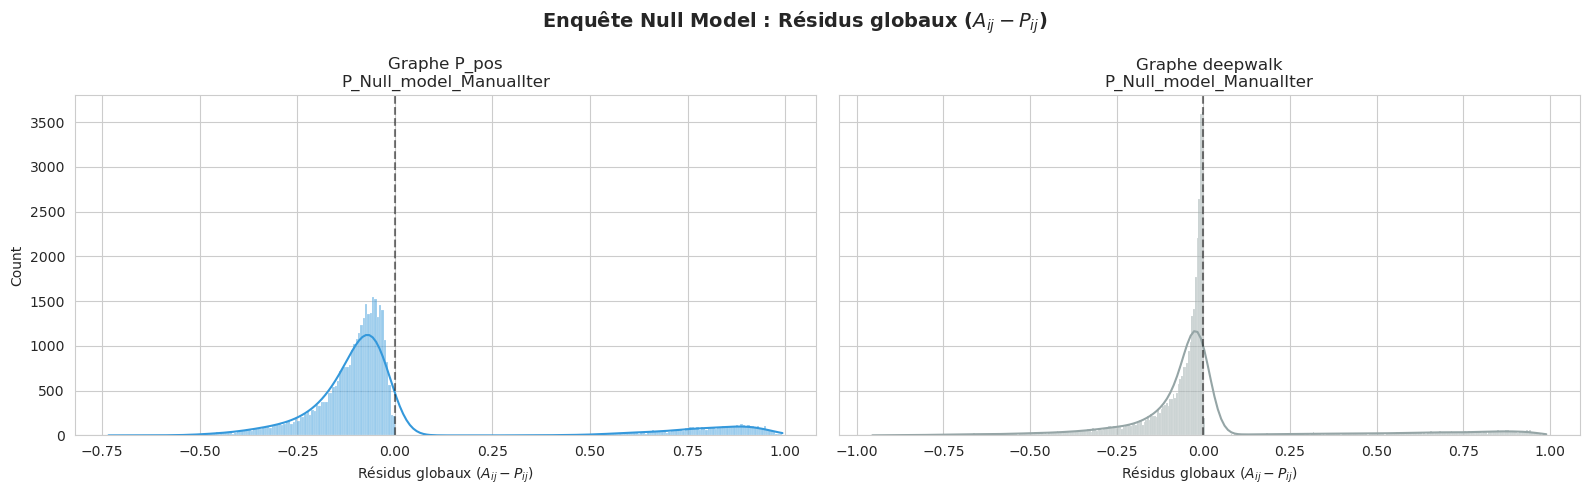

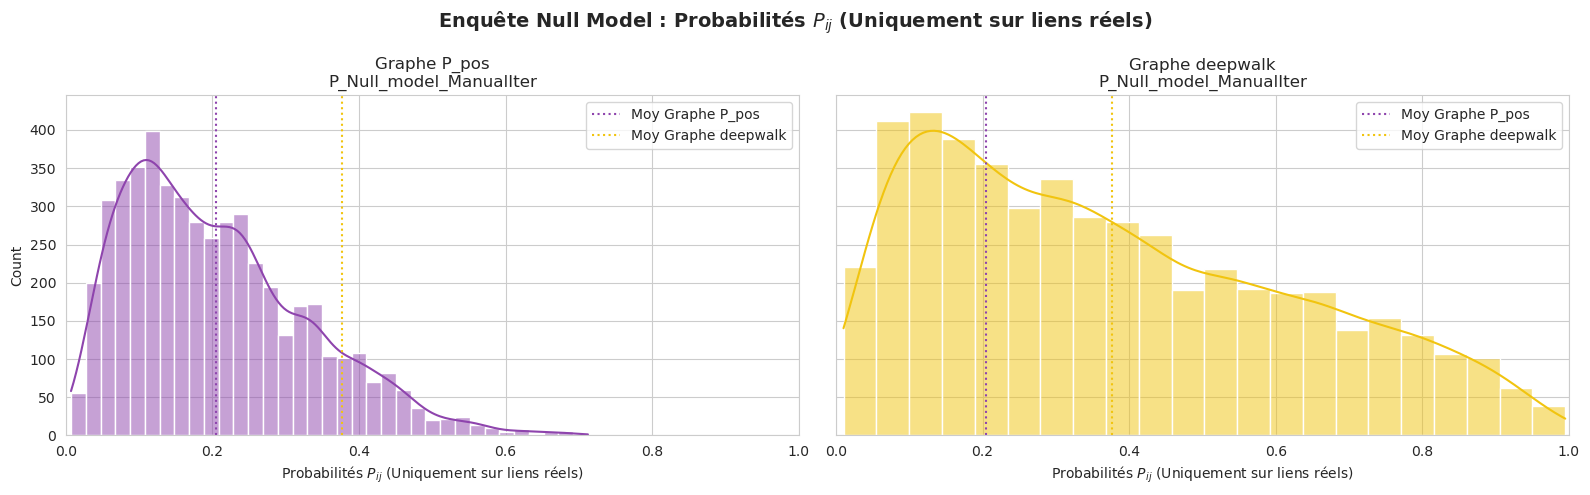

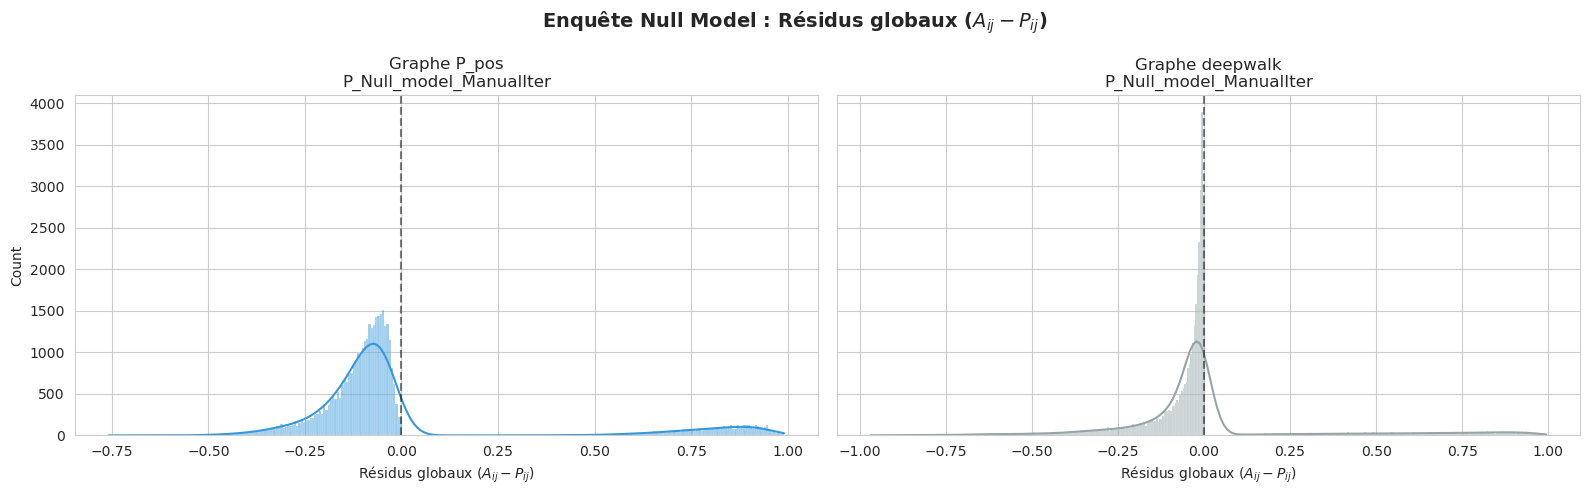

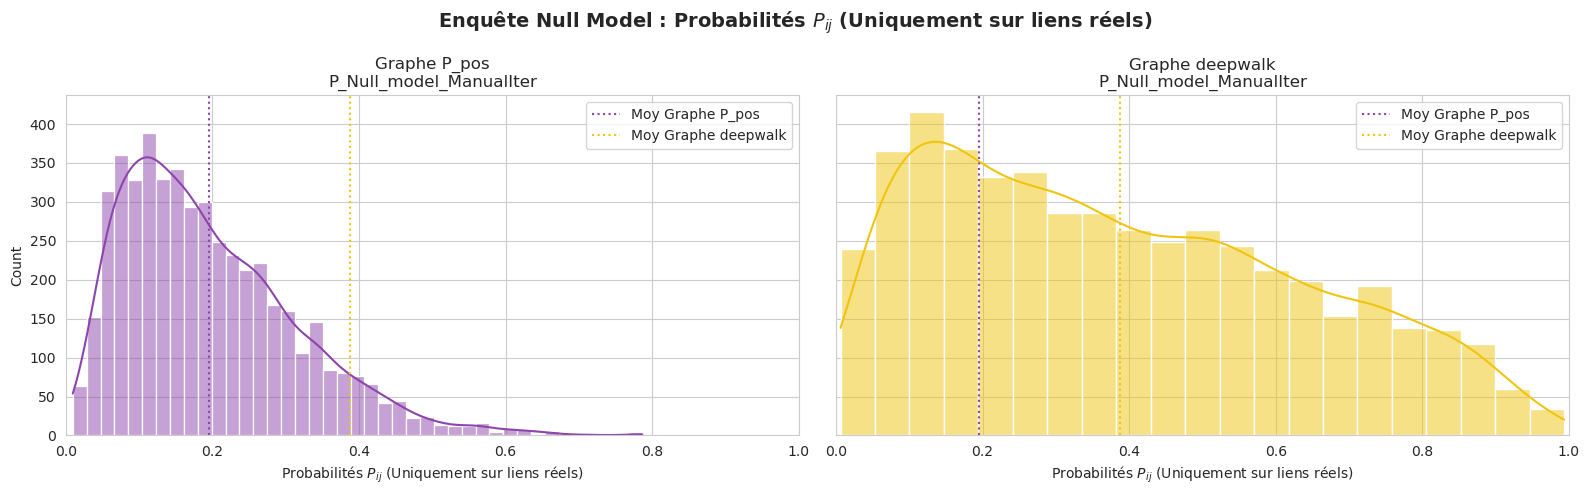

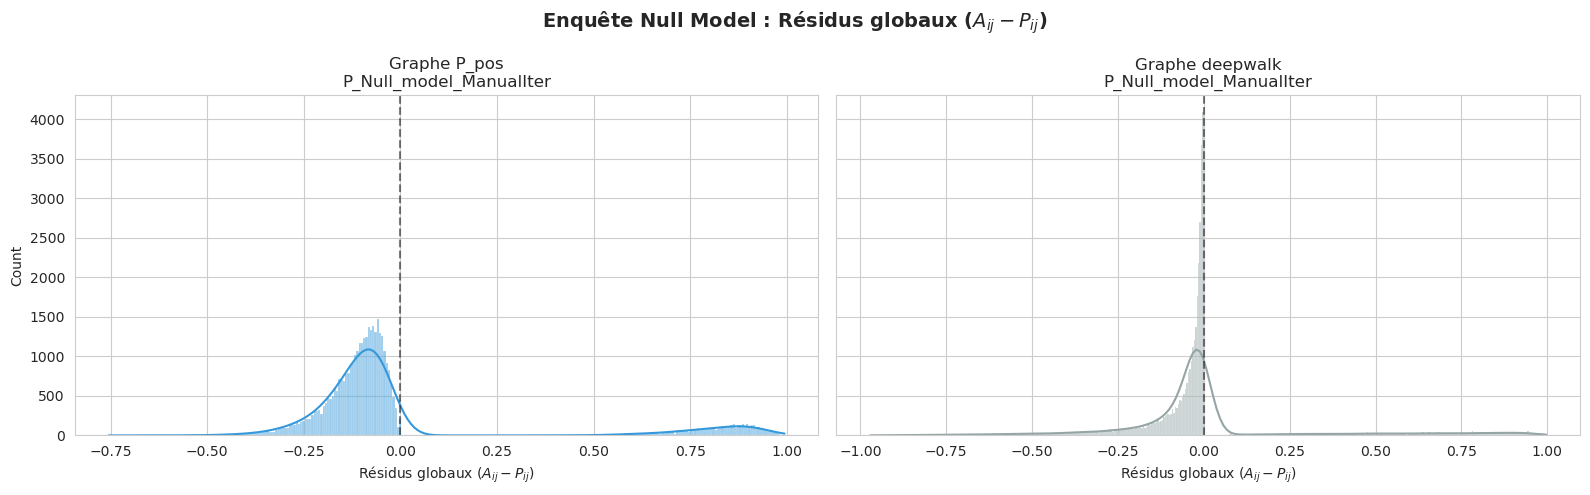

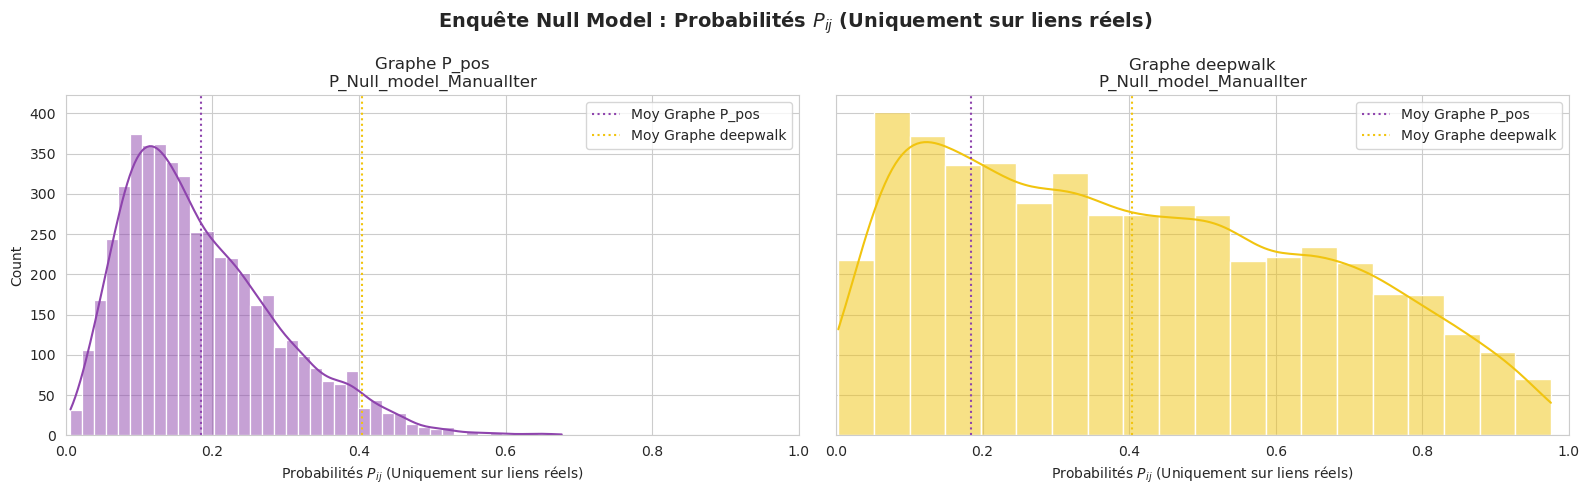

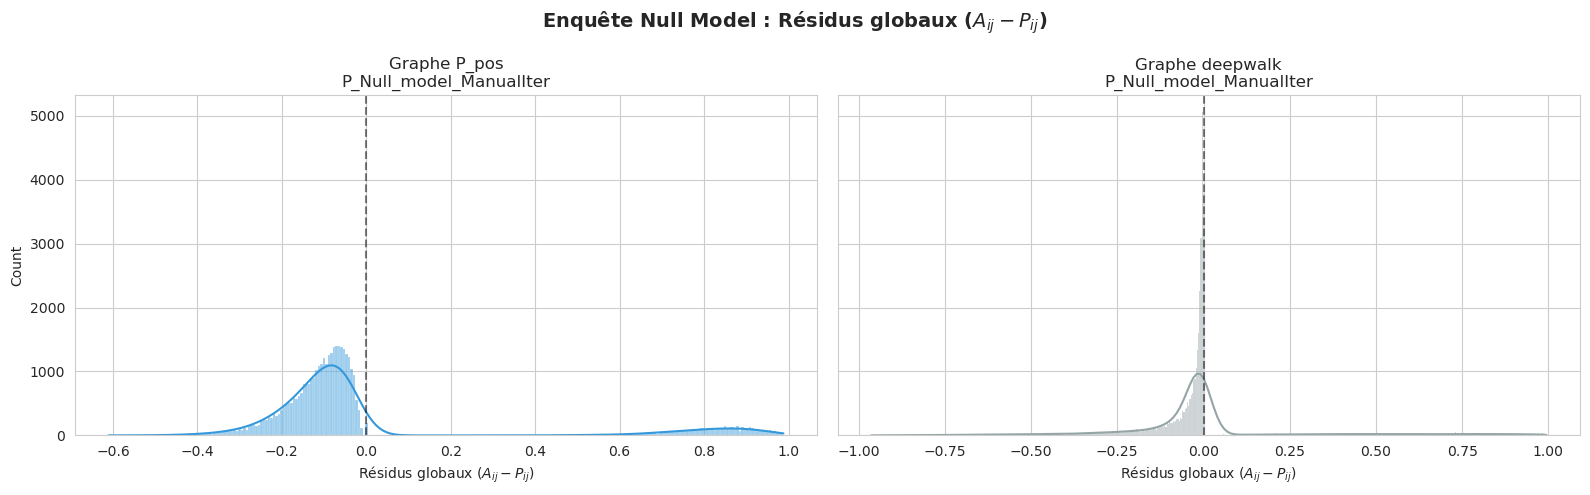

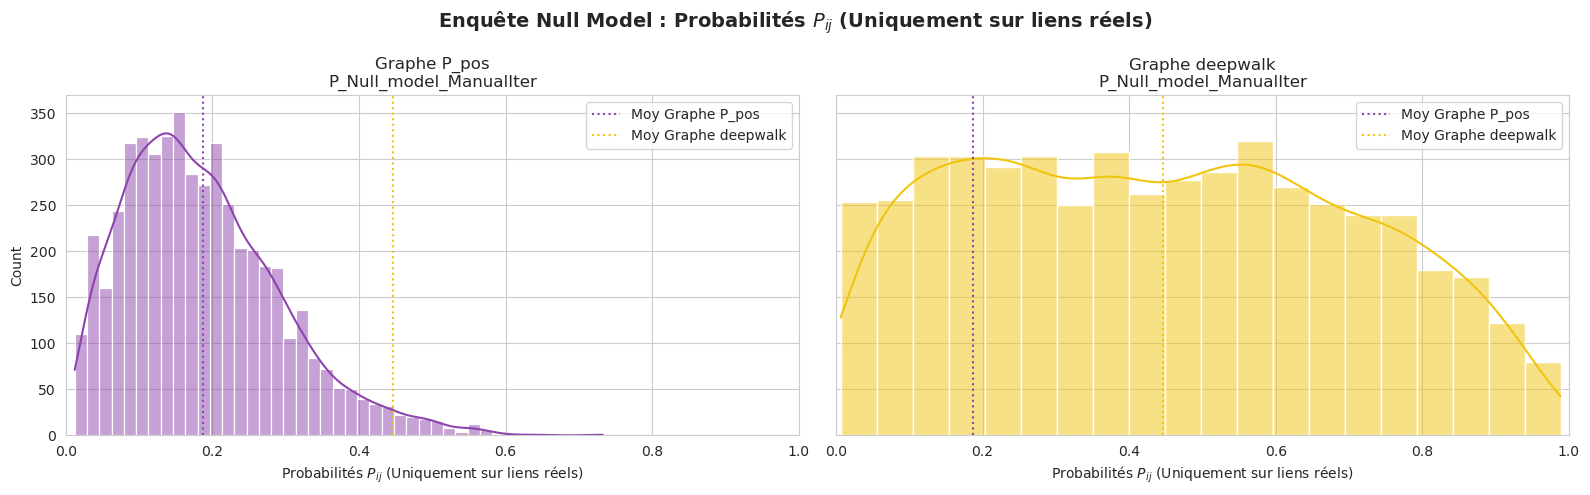

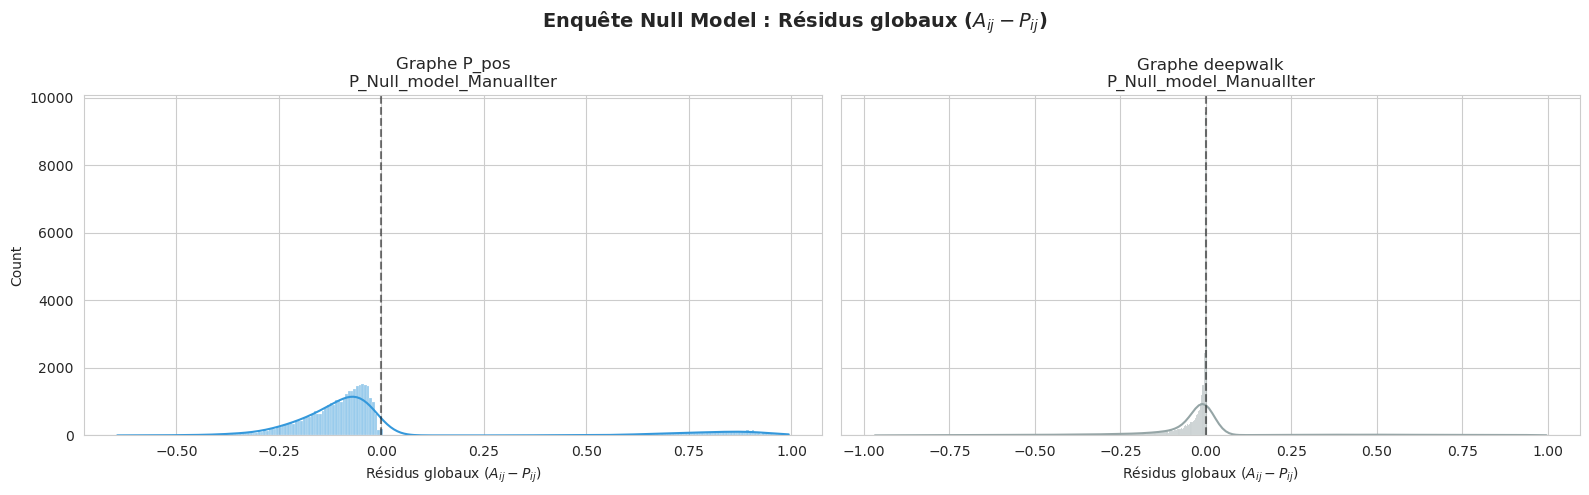

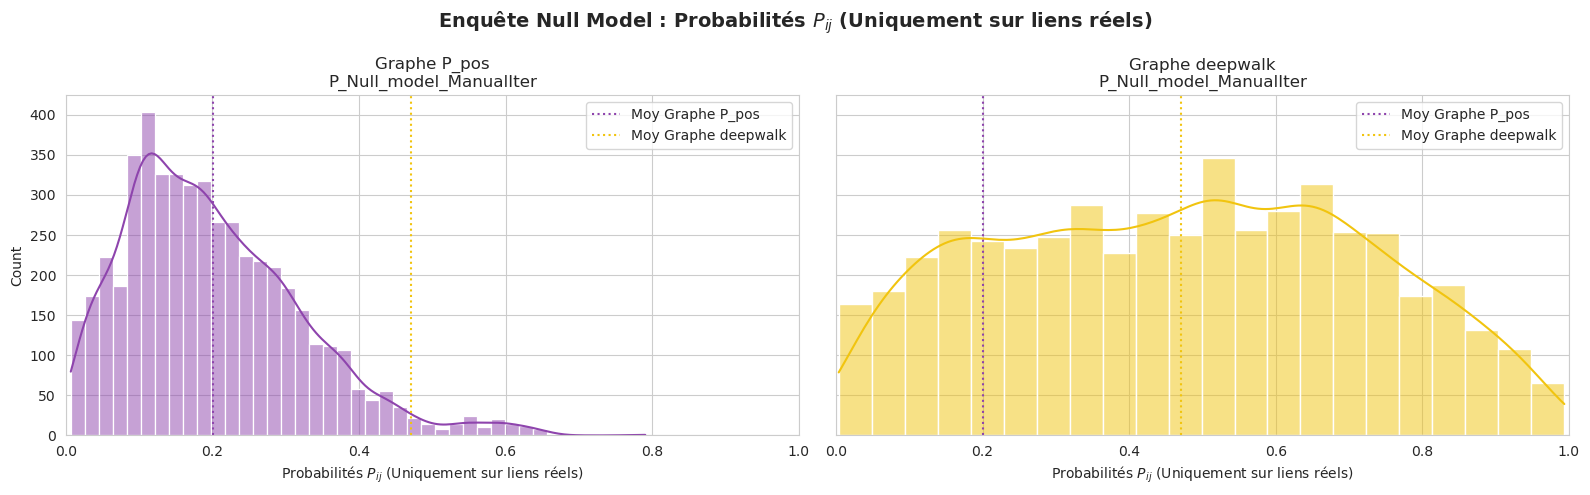

In [49]:
for i_rep in range(1, 2):
    for j in np.arange(0.00, 1.10, 0.10):
        sbm_val = f"{j:.2f}"
        pos_val = f"{1-j:.2f}"
        #G_name = f"artificial_graph_sbmv4_{sbm_val.replace('.', '_')}_pos_{pos_val.replace('.', '_')}"
        G_name = f"artificial_graph_sbmv4_{sbm_val.replace('.', '_')}_pos_{pos_val.replace('.', '_')}_{i_rep}"
        
        # 1. Chargement des données d'entraînement
        #Graph, dataset_train, dataset_eval, _, _, _ = gp.load_all_data_for_graph(G_name)
        Graph_GT_Pos = gp.loadsave_data_joblib(data=None, filename=f"G_kept_w_struct_com_dist_{G_name}", mode="load")
        Graph_deepwalk = gp.loadsave_data_joblib(data=None, filename=f"G_kept_w_struct_com_dist_{G_name}_deepwalk", mode="load")

        print("="*60)
        print(f"--------- sbm_val {sbm_val} Iter {i_rep} ---------")
        print("="*60)
        plot_null_model_comparison(Graph_GT_Pos, Graph_deepwalk, mode="residuals", p_matrix_name="P_Null_model_ManualIter")
        plot_null_model_comparison(Graph_GT_Pos, Graph_deepwalk, mode="probabilities", p_matrix_name="P_Null_model_ManualIter")


## 2 - Exploration des Shap values

### 2.1 - Concaténation des Shap_Values pour toutes les valeurs de ratio_sbm

In [15]:
all_summaries = []

for i in np.arange(0, 1.10, 0.10):
    sbm_val = f"{i:.2f}"
    pos_val = f"{1-i:.2f}"
    G_name = f"artificial_graph_sbmv4_{sbm_val.replace('.', '_')}_pos_{pos_val.replace('.', '_')}"
    
    _, _, _, xgboost_data, shap_explainer, _ = gp.load_all_data_for_graph(G_name)
    X_test = xgboost_data['X_test']

    print(f"Type de l'objet : {type(shap_explainer)}")
    print(f"Dimensions des valeurs : {shap_explainer.values.shape}")

    vals = shap_explainer.values
    
    if isinstance(vals, list):
        vals = vals[1]

    df_shap = pd.DataFrame(vals, columns=X_test.columns)
    mean_shap = df_shap.mean()
    mean_abs_shap = df_shap.abs().mean()
    
    summary = pd.DataFrame({
        'feature': X_test.columns,
        'mean_shap': mean_shap.values,
        'mean_abs_shap': mean_abs_shap.values,
        'sbm_param': i
    })
    all_summaries.append(summary)

df_shapvals_concat = pd.concat(all_summaries)


SHAP Analysis introuvable pour artificial_graph_sbmv4_0_00_pos_1_00.
Type de l'objet : <class 'shap._explanation.Explanation'>
Dimensions des valeurs : (556, 50)
SHAP Analysis introuvable pour artificial_graph_sbmv4_0_10_pos_0_90.
Type de l'objet : <class 'shap._explanation.Explanation'>
Dimensions des valeurs : (536, 50)
SHAP Analysis introuvable pour artificial_graph_sbmv4_0_20_pos_0_80.
Type de l'objet : <class 'shap._explanation.Explanation'>
Dimensions des valeurs : (540, 50)
SHAP Analysis introuvable pour artificial_graph_sbmv4_0_30_pos_0_70.
Type de l'objet : <class 'shap._explanation.Explanation'>
Dimensions des valeurs : (556, 50)
SHAP Analysis introuvable pour artificial_graph_sbmv4_0_40_pos_0_60.
Type de l'objet : <class 'shap._explanation.Explanation'>
Dimensions des valeurs : (556, 50)
SHAP Analysis introuvable pour artificial_graph_sbmv4_0_50_pos_0_50.
Type de l'objet : <class 'shap._explanation.Explanation'>
Dimensions des valeurs : (552, 50)
SHAP Analysis introuvable po

### 2.2 - Plot des shap_values par sbm_ratio et par feature

Graphique sauvegardé sous : outputs/plots/heatmap_feat_importance_per_ratio_v5_reduced_GT_mean_abs_shap.png


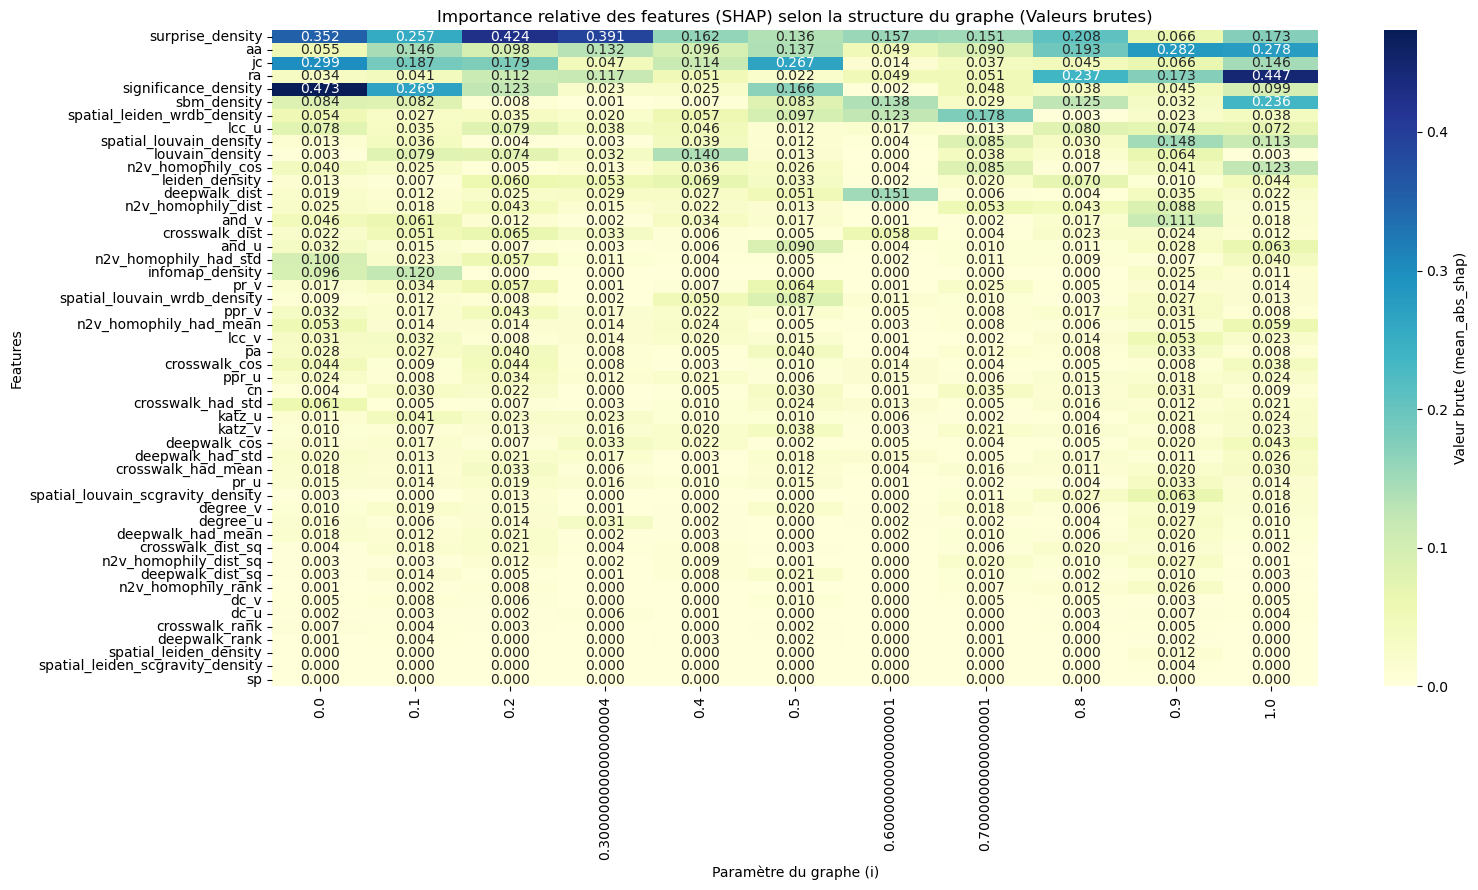

Index(['feature', 'mean_shap', 'mean_abs_shap', 'sbm_param'], dtype='object')
cn, aa, ra, jc, pa, sp, degree_u, degree_v, pr_u, pr_v, ppr_u, ppr_v, lcc_u, lcc_v, and_u, and_v, dc_u, dc_v, katz_u, katz_v, louvain_density, infomap_density, sbm_density, leiden_density, surprise_density, significance_density, spatial_leiden_density, spatial_louvain_density, spatial_leiden_scgravity_density, spatial_louvain_scgravity_density, spatial_leiden_wrdb_density, spatial_louvain_wrdb_density, n2v_homophily_cos, n2v_homophily_dist, n2v_homophily_dist_sq, n2v_homophily_had_mean, n2v_homophily_had_std, deepwalk_cos, deepwalk_dist, deepwalk_dist_sq, deepwalk_had_mean, deepwalk_had_std, crosswalk_cos, crosswalk_dist, crosswalk_dist_sq, crosswalk_had_mean, crosswalk_had_std, n2v_homophily_rank, deepwalk_rank, crosswalk_rank, cn, aa, ra, jc, pa, sp, degree_u, degree_v, pr_u, pr_v, ppr_u, ppr_v, lcc_u, lcc_v, and_u, and_v, dc_u, dc_v, katz_u, katz_v, louvain_density, infomap_density, sbm_density, leiden_den

'\nall_distribs = []\nfor i in np.arange(0, 1.05, 0.05):\n    sbm_val = f"{i:.2f}"\n    pos_val = f"{1-i:.2f}"\n    G_name = f"artificial_graph_sbm_{sbm_val.replace(\'.\', \'_\')}_pos_{pos_val.replace(\'.\', \'_\')}"\n    \n    _, _,_, xgboost_data, _, _ = gp.load_all_data_for_graph(G_name)\n    X_test = xgboost_data[\'X_test\']\n    y_test = xgboost_data[\'y_test\']\n    \n    pos_sp = X_test[y_test == 1][\'sp\'].value_counts(normalize=True).to_dict()\n    neg_sp = X_test[y_test == 0][\'sp\'].value_counts(normalize=True).to_dict()\n    \n    row = {\'sbm_param\': round(i, 2)}\n    for dist in range(1, 7):\n        row[f\'pos_sp_{dist}\'] = pos_sp.get(dist, 0)\n        row[f\'neg_sp_{dist}\'] = neg_sp.get(dist, 0)\n    \n    row[\'pos_sp_7+\'] = sum(v for k, v in pos_sp.items() if k >= 7 or k == 0)\n    row[\'neg_sp_7+\'] = sum(v for k, v in neg_sp.items() if k >= 7 or k == 0)\n    \n    all_distribs.append(row)\n\ndf_sp_detailed = pd.DataFrame(all_distribs)\n\ncols = [\'sbm_param\'] +

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

def plot_feature_importance_evolution(df_results, metric="mean_shap", as_ratio=True):
    """
    Génère une heatmap montrant l'évolution de l'importance des features (SHAP).
    """
    heatmap_data = df_results.pivot(index='feature', columns='sbm_param', values=metric)
    
    if as_ratio:
        heatmap_data = heatmap_data.div(heatmap_data.sum(axis=0), axis=1)
        label_name = f"Ratio de contribution ({metric})"
        fmt_type = ".2%"
    else:
        label_name = f"Valeur brute ({metric})"
        fmt_type = ".3f"

    heatmap_data['avg_importance'] = heatmap_data.mean(axis=1)
    heatmap_data = heatmap_data.sort_values(by='avg_importance', ascending=False).drop(columns='avg_importance')

    plt.figure(figsize=(16, 9))
    sns.heatmap(heatmap_data, annot=True, fmt=fmt_type, cmap="YlGnBu", yticklabels=True, cbar_kws={'label': label_name})

    title_suffix = "(Ratios normalisés)" if as_ratio else "(Valeurs brutes)"
    plt.title(f"Importance relative des features (SHAP) selon la structure du graphe {title_suffix}")
    plt.xlabel("Paramètre du graphe (i)")
    plt.ylabel("Features")
    plt.tight_layout()

    filename = f"outputs/plots/heatmap_feat_importance_per_ratio_v5_reduced_GT_{metric}.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"Graphique sauvegardé sous : {filename}")
    plt.show()

plot_feature_importance_evolution(df_shapvals_concat, metric="mean_abs_shap", as_ratio=False)
print(df_shapvals_concat.columns)
features_list = df_shapvals_concat['feature']
print(", ".join(map(str, features_list)))

"""
all_distribs = []
for i in np.arange(0, 1.05, 0.05):
    sbm_val = f"{i:.2f}"
    pos_val = f"{1-i:.2f}"
    G_name = f"artificial_graph_sbm_{sbm_val.replace('.', '_')}_pos_{pos_val.replace('.', '_')}"
    
    _, _,_, xgboost_data, _, _ = gp.load_all_data_for_graph(G_name)
    X_test = xgboost_data['X_test']
    y_test = xgboost_data['y_test']
    
    pos_sp = X_test[y_test == 1]['sp'].value_counts(normalize=True).to_dict()
    neg_sp = X_test[y_test == 0]['sp'].value_counts(normalize=True).to_dict()
    
    row = {'sbm_param': round(i, 2)}
    for dist in range(1, 7):
        row[f'pos_sp_{dist}'] = pos_sp.get(dist, 0)
        row[f'neg_sp_{dist}'] = neg_sp.get(dist, 0)
    
    row['pos_sp_7+'] = sum(v for k, v in pos_sp.items() if k >= 7 or k == 0)
    row['neg_sp_7+'] = sum(v for k, v in neg_sp.items() if k >= 7 or k == 0)
    
    all_distribs.append(row)

df_sp_detailed = pd.DataFrame(all_distribs)

cols = ['sbm_param'] + [f'{prefix}_sp_{d}' for d in list(range(1, 7)) + ['7+'] for prefix in ['pos', 'neg']]
df_sp_detailed = df_sp_detailed[cols]

pd.options.display.float_format = '{:.3f}'.format
print(df_sp_detailed.to_string(index=False))
"""

### 2.3 - Exploration du ranking des SHAP vals des features sur chaque paire (voir si qq métriques on avg pas ouf perfs fort sur qq paires) 

In [ ]:
def plot_feature_importance_heatmap(df_results, output_filename="heatmap_shap_percentage_presence_top_k.png"):
    """
    Génère une heatmap dynamique selon le ratio présent dans le DataFrame.
    """
    ratio_col = [c for c in df_results.columns if '_ratio' in c][0]
    k_val = ratio_col.replace('top', '').replace('_ratio', '')

    heatmap_data = df_results.pivot(index='feature', columns='sbm_param', values=ratio_col)
    
    heatmap_data['avg'] = heatmap_data.mean(axis=1)
    heatmap_data = heatmap_data.sort_values('avg', ascending=False).drop(columns='avg')

    plt.figure(figsize=(14, 8))
    sns.heatmap(heatmap_data, 
                annot=True, 
                fmt=".1%", 
                cmap="YlGnBu", 
                cbar_kws={'label': f'% de présence au Top {k_val} (SHAP)'})

    plt.title(f"Évolution de la dominance des features (Top {k_val})")
    plt.xlabel("Paramètre SBM (i)")
    plt.ylabel("Features")
    
    os.makedirs("outputs/plots", exist_ok=True)
    plt.savefig(f"outputs/plots/{output_filename}", dpi=300, bbox_inches='tight')
    plt.show()


results_list = []
k_target = 3 

for i in np.arange(0, 1.05, 0.25):
    sbm_val = f"{i:.2f}"
    pos_val = f"{1-i:.2f}"
    G_name = f"artificial_graph_sbmv2_{sbm_val.replace('.', '_')}_pos_{pos_val.replace('.', '_')}"
    
    try:
        _, _, _, xgboost_data, shap_explainer, _ = gp.load_all_data_for_graph(G_name)
        vals = shap_explainer.values
        if isinstance(vals, list): vals = vals[1]

        df_ranks = gp.calculate_feature_rankings(vals, xgboost_data['X_test'].columns, top_k=k_target, plot=False)
        
        top_k_sum = df_ranks.iloc[0:k_target, :].sum(axis=0)
        
        for feat_name, val in top_k_sum.items():
            results_list.append({
                'sbm_param': i,
                'feature': feat_name,
                f'top{k_target}_ratio': val / 100  
            })
            
    except Exception as e:
        print(f"Skipping {G_name} due to error: {e}")

df_shap_rankings = pd.DataFrame(results_list)

plot_feature_importance_heatmap(df_shap_rankings)

### 2.4 - Explo locale des shap values par catégorie & corrélations

In [20]:
from scipy import stats

def plot_Dominance_Index_VS_probas(explainability_dataset, ax, ratio_sbm):
    rho, _ = stats.spearmanr(explainability_dataset["Dominance_probas_Index"], explainability_dataset["Dominance_Index"])
    
    sns.regplot(
        data=explainability_dataset,
        x="Dominance_probas_Index",
        y="Dominance_Index",
        scatter_kws={'alpha': 0.3, 's': 10, 'color': 'steelblue'}, # Couleur de base
        line_kws={'color': 'red', 'linewidth': 2}, # Ligne de tendance rouge
        ax=ax # IMPORTANT : On dessine sur l'axe donné
    )
    
    ax.axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.5)
    ax.axvline(0, color='black', linewidth=1, linestyle='--', alpha=0.5)
    
    ax.set_title(f"Ratio SBM: {ratio_sbm:.2f} ($\\rho$={rho:.2f})")
    ax.set_xlim(-1.1, 1.1)
    ax.set_ylim(-1.1, 1.1)
    ax.set_xlabel("Probas (Spatial < 0 | SBM > 0)")
    
    if ax.get_subplotspec().is_first_col():
        ax.set_ylabel("SHAP (Embed < 0 | Commu > 0)")
    else:
        ax.set_ylabel("")
        
    ax.grid(alpha=0.3)
    

def test_Mann_Whitney(explainability_dataset, silent = True) :
    rho, p_val_rho = stats.spearmanr(explainability_dataset["Dominance_probas_Index"], 
                                     explainability_dataset["Dominance_Index"])
    
    group_spatial = explainability_dataset[explainability_dataset["Dominance_probas_Index"] < 0]["Dominance_Index"]
    group_sbm = explainability_dataset[explainability_dataset["Dominance_probas_Index"] > 0]["Dominance_Index"]
    
    # 3. Test de significativité (Mann-Whitney U car les distributions ne sont sûrement pas normales, se base sur les rangs)
    u_stat, p_val_test = stats.mannwhitneyu(group_spatial, group_sbm)

    if silent == False : 
        print(f"=== ANALYSE STATISTIQUE ===")
        print(f"Corrélation de Spearman : {rho:.4f} (p-value: {p_val_rho:.2e})")
        print(f"Moyenne Dominance SHAP (Groupe Spatial) : {group_spatial.mean():.4f}")
        print(f"Moyenne Dominance SHAP (Groupe SBM)     : {group_sbm.mean():.4f}")
        print(f"Différence significative (Mann-Whitney) : {'OUI' if p_val_test < 0.05 else 'NON'} (p={p_val_test:.2e})")

    return {
        "rho": rho,
        "p_val_test": p_val_test,
        "mean_spatial": group_spatial.mean(),
        "mean_sbm": group_sbm.mean()
    }

SHAP Analysis introuvable pour artificial_graph_sbmv4_1_00_pos_0_00_GT.
   u   v  target     proba  SHAP_Groupe_Embeddings  SHAP_Groupe_Communities  \
0  0  19       1  0.251146                0.014440                 0.654105   
1  0   6       1  0.170210                0.004708                 0.580387   

   Dominance_Index  p_uv_sbm  p_uv_pos  p_uv_hyb  Dominance_probas_Index  
0         0.956801  0.272727  0.002341  0.272727                0.982980  
1         0.983908  0.241667  0.009376  0.241667                0.925301  
SHAP Analysis introuvable pour artificial_graph_sbmv4_0_75_pos_0_25_GT.
   u   v  target     proba  SHAP_Groupe_Embeddings  SHAP_Groupe_Communities  \
0  0  81       1  0.131576                0.191993                 0.342465   
1  0   8       1  0.211974                0.140949                 1.039547   

   Dominance_Index  p_uv_sbm  p_uv_pos  p_uv_hyb  Dominance_probas_Index  
0         0.281542  0.166667  0.069923  0.142481                0.408907  
1    

/var/folders/c1/t05kmpw95cg2nqvcvcdvhd200000gn/T/ipykernel_29165/4273595977.py:102: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  print(p_val_summary.applymap(lambda x: f"{x:.2e}").reset_index().to_string(index=False))


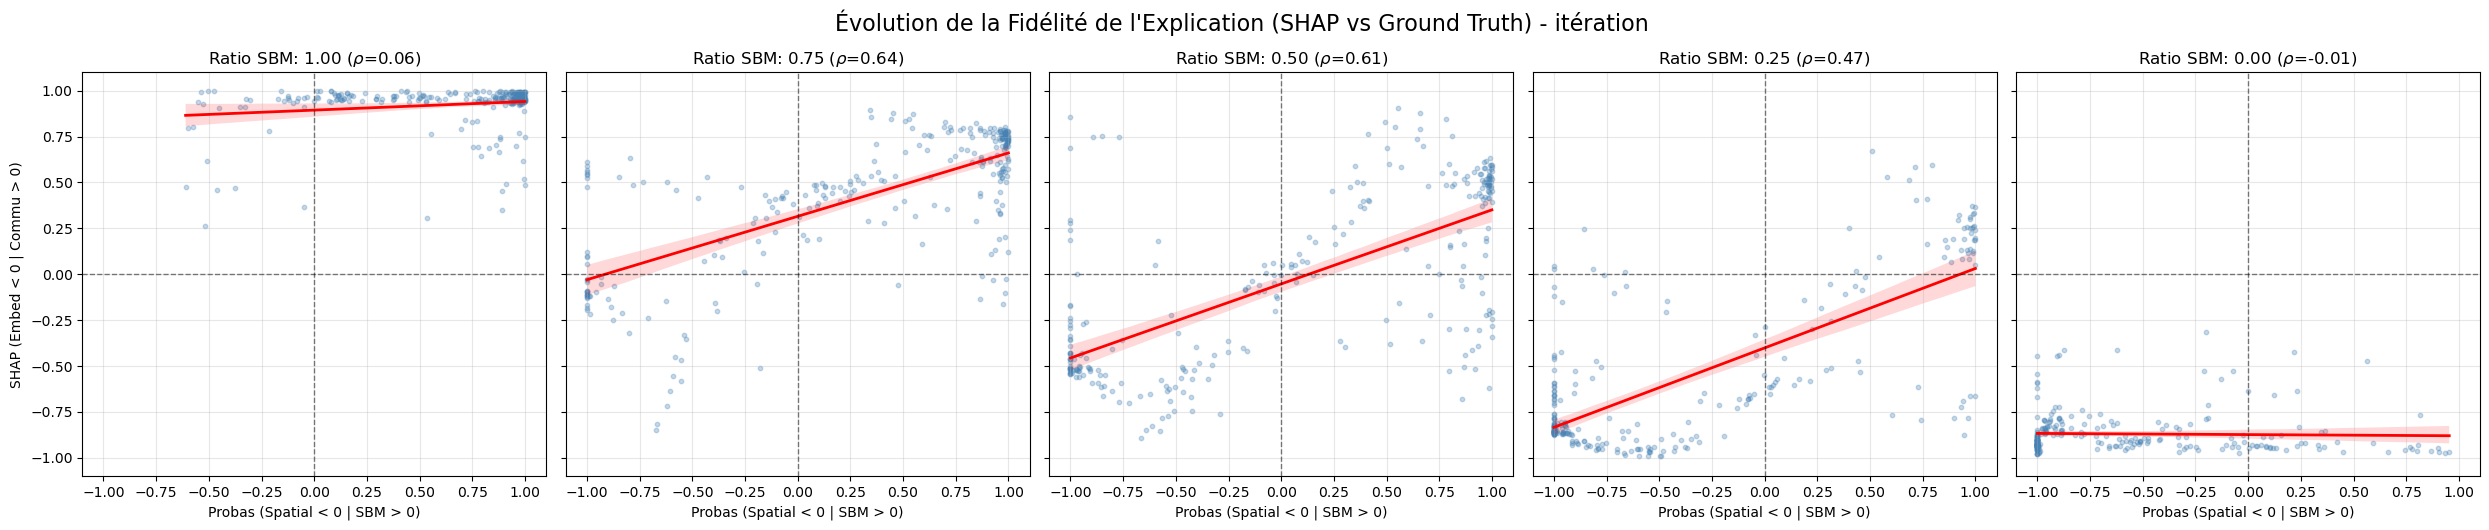

In [23]:
from scipy import stats

feature_mapping = {
        "Groupe_Structure": ['pr_u', 'pr_v','ppr_u', 'ppr_v', 'lcc_u', 'lcc_v', 'and_u', 'and_v', 'dc_u', 'dc_v', 'katz_u', 'katz_v',
                              'sp', 'jc', 'aa', 'cn','pa', 'ra'],
        "Groupe_Communities": ['louvain_density', 'same_louvain', 'infomap_density', 'same_infomap', 'sbm_density', 'same_sbm',
                            'leiden_density', 'same_leiden', "surprise_density", "same_surprise", 
                            "significance_density", "same_significance"],
        "Groupe_Embeddings": ["deepwalk_cos", "deepwalk_rank", "deepwalk_had_mean",  "deepwalk_had_std",
                        "n2v_homophily_cos", "n2v_homophily_rank", "n2v_homophily_had_mean",  "n2v_homophily_had_std",
                      "crosswalk_cos", "crosswalk_rank", "crosswalk_had_mean",  "crosswalk_had_std"]
}

feature_mapping = {
    "Groupe_Embeddings": ['GT_pos_dist', 'GT_spatial_deg_product'],
    "Groupe_Communities": ['GT_sbm_density', 'GT_sbm_deg_product']
}

#p_matrices = joblib.load("graph_library/artificial_graph_sbmv5_P_matrices.joblib")
correlations_recap = []
Mann_Whitney_recap = []
fig, axes = plt.subplots(1, 5, figsize=(25, 5), sharey=True)
plot_idx = 0

for j in [""] :
    for i in np.arange(1.00, -0.25, -0.25):
        sbm_val = f"{i:.2f}"
        pos_val = f"{1-i:.2f}"
        G_name = f"artificial_graph_sbmv4{j}_{sbm_val.replace('.', '_')}_pos_{pos_val.replace('.', '_')}_GT"
        G_name_reduced = f"artificial_graph_sbmv4{j}_{sbm_val.replace('.', '_')}_pos_{pos_val.replace('.', '_')}_reduced_GT"

        
        G, _, dataset_hidden, xgboost_data, shap_explainer, _ = gp.load_all_data_for_graph(G_name)
        #_, _, _, xgboost_data, shap_explainer, _ = gp.load_all_data_for_graph(G_name_reduced)

        p_matrices = joblib.load(f"graph_library/artificial_graph_sbmv4{j}_P_matrices.joblib")
    
        explainability_dataset = gput.build_explainability_dataset(shap_explainer, xgboost_data, dataset_hidden, feature_mapping, 
                                                                   p_matrices_origin =p_matrices, ratio_sbm=i)

    
        explainability_dataset["Dominance_probas_Index"] = (explainability_dataset["p_uv_sbm"]-explainability_dataset["p_uv_pos"]) / (explainability_dataset["p_uv_sbm"]+explainability_dataset["p_uv_pos"])
    
        print(explainability_dataset.head(2))
        if i == 0.25 :
            gput.plot_pyvis_eval_graph_map(explainability_dataset, G, G_name,  filename="logic_map.html")
        #gput.plot_dominance_distribution(explainability_dataset, title = f"Distribution de la Dominance (Spatial vs SBM) - ratio_sbm = {i}")
        if plot_idx < 5:
            plot_Dominance_Index_VS_probas(explainability_dataset, axes[plot_idx], i)
            plot_idx += 1
        
        # --- Test statistique Mann_Whitney entre "Dominance_probas_Index" & "Dominance_Index" ---
        Mann_Whitney = test_Mann_Whitney(explainability_dataset, silent=True)
        Mann_Whitney["ratio_sbm"] = i 
        Mann_Whitney_recap.append(Mann_Whitney)

        # --- Test statistique spearman entre "Dominance_probas_Index" & "Dominance_Index" ---
        s_corr, s_p = stats.kendalltau(explainability_dataset["Dominance_Index"], explainability_dataset["Dominance_probas_Index"])
    
        # --- Coefficients de Corrélation avec Dominance_idex ---
        row = {
            "ratio_sbm": i,
            "SHAP_Probas_Kendall": round(s_corr, 4),
            "SHAP_Probas_P_Value": s_p
        }
        colonnes_p = ["p_uv_sbm", "p_uv_pos", "p_uv_hyb"]
        groupes_shap = {"SHAP_Groupe_Communities": "Com",
                        "SHAP_Groupe_Embeddings": "Emb"
                        #"SHAP_Groupe_Structure": "Str"
                       }
    
        for full_name, short_name in groupes_shap.items():
            for p_col in colonnes_p:
                corr = explainability_dataset[full_name].corr(explainability_dataset[p_col], method = "kendall")
                suffix = p_col.split('_')[-1]
                col_name = f"{short_name}_{suffix}"
                row[col_name] = round(corr, 4)
    
        correlations_recap.append(row)

correlations_recap = pd.DataFrame(correlations_recap)

print("\n=== TABLEAU RÉCAPITULATIF DES CORRÉLATIONS de plusieurs itérations ===")
print(correlations_recap.to_string(index=False))

print("\n=== SYNTHÈSE DES CORRÉLATIONS (MOYENNE ET ÉCART-TYPE) ===")
stats = correlations_recap.groupby("ratio_sbm").agg(["mean", "std", "min", "max"])
final_table = pd.DataFrame(index=stats.index)

for col in stats.columns.levels[0]:
    if col == "ratio_sbm": continue
    final_table[col] = stats[col].apply(
        lambda x: f"{x['mean']:.3f} ({x['std']:.3f})", axis=1
    )

print(final_table.reset_index().to_string(index=False))

print("\n=== RÉCAPITULATIF STATISTIQUE (MANN-WHITNEY P-VALUE) ===")
Mann_Whitney_stats = pd.DataFrame(Mann_Whitney_recap)
p_val_summary = Mann_Whitney_stats.groupby("ratio_sbm")["p_val_test"].agg(["mean", "std", "min", "max"])
print(p_val_summary.applymap(lambda x: f"{x:.2e}").reset_index().to_string(index=False))

print("\n=== PLOTS GLOBAUX DES DOMINANCE INDEXES ===")
plt.tight_layout()
fig.suptitle(f"Évolution de la Fidélité de l'Explication (SHAP vs Ground Truth) - itération {j}", fontsize=16, y=1.05)
plt.savefig("outputs/plots/evolution_dominance_debiaisée_multi_ratio_v4_20260415.png", bbox_inches='tight')
plt.show()

## 3 - Exploration des features et groupes de features

### 3.1 - Correlation des features entre elles

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform

RRRRRRRRRRRRATIO i : 0
Features ac 1 unique valeur pour rati_sbm=0.00 :    sbm_density  same_sbm
0     0.023002         1
Graphique sauvegardé : outputs/plots/correlation_clustermap_sbm_0_00.png


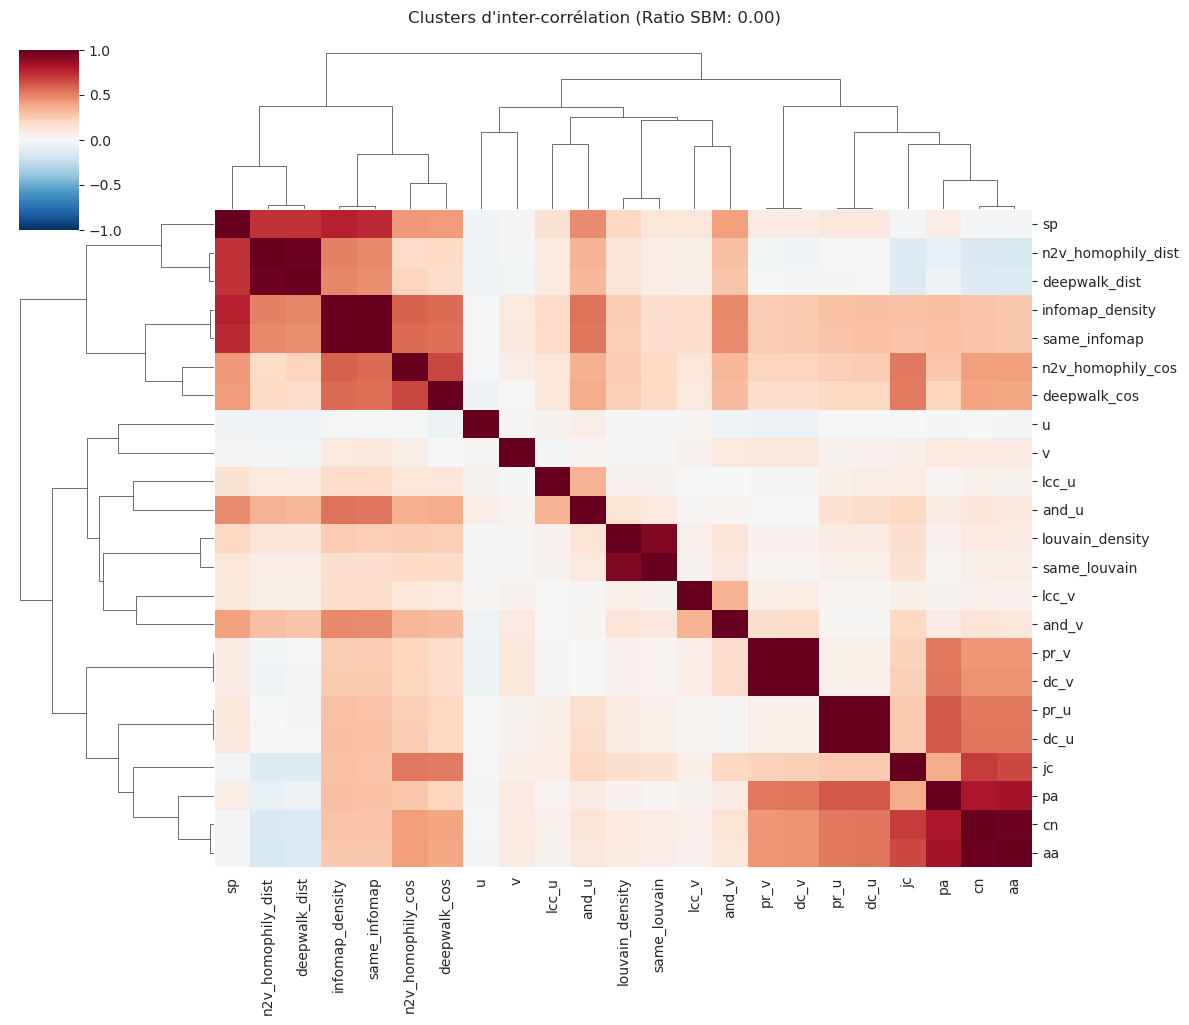

NameError: name 'hierarchy' is not defined

<Figure size 1000x500 with 0 Axes>

In [67]:
# On garde tes groupes pour l'analyse
group_mapping = {
    "Groupe_Structure": ['cn', 'aa', 'jc', 'pa', 'sp', 'pr_u', 'pr_v', 'lcc_u', 'lcc_v', 'and_u', 'and_v', 'dc_u', 'dc_v'],
    "Groupe_Communities": ['sbm_density', 'same_sbm', 'infomap_density', 'same_infomap',"louvain_density", "same_louvain"],
    "Groupe_Embeddings": ['n2v_homophily_cos', 'n2v_homophily_dist', 'deepwalk_cos', 'deepwalk_dist']
}

output_folder = "outputs/plots"
os.makedirs(output_folder, exist_ok=True)

ratios = [0, 0.25, 0.50, 0.75, 1.00]
for i in ratios:
    print(f"RRRRRRRRRRRRATIO i : {i}")
    sbm_val_str = f"{i:.2f}"
    pos_val_str = f"{1-i:.2f}"
    G_name = f"artificial_graph_sbmv2_{sbm_val_str.replace('.', '_')}_pos_{pos_val_str.replace('.', '_')}"
    
    _, dataset_train, _, _, _, _ = gp.load_all_data_for_graph(G_name)    
    features = [c for c in dataset_train.columns if c != 'target']
    df_features = dataset_train[features]

    print(f"Features ac 1 unique valeur pour rati_sbm={sbm_val_str} : {df_features.loc[:, df_features.nunique() <= 1].head(1)}")
    df_features = df_features.loc[:, df_features.nunique() > 1]

    # --- CALCUL DE LA MATRICE DE CORRÉLATION ---
    corr_matrix = df_features.corr(method='pearson')
    
    # --- PLOT 1 : CLUSTERMAP (La vue d'ensemble) ---
    # Combine la heatmap et le dendrogramme
    g = sns.clustermap(corr_matrix, 
                       method='complete', 
                       cmap='RdBu_r', 
                       vmin=-1, vmax=1,
                       figsize=(12, 10))
    g.fig.suptitle(f"Clusters d'inter-corrélation (Ratio SBM: {sbm_val_str})", y=1.02)
    
    save_path = os.path.join(output_folder, f"correlation_clustermap_sbm_{sbm_val_str.replace('.', '_')}.png")
    plt.savefig(save_path, bbox_inches='tight', dpi=300)
    print(f"Graphique sauvegardé : {save_path}")

    plt.show()

    # --- PLOT 2 : DENDROGRAMME PUR (Focus structure) ---
    plt.figure(figsize=(10, 5))
    features_clean = df_features.columns.tolist()
    # Distance = 1 - valeur absolue de la corrélation
    dissimilarity = 1 - np.abs(corr_matrix)
    # Linkage sur la matrice de corrélation nettoyée
    Z = hierarchy.linkage(squareform(dissimilarity, checks=False), method='complete')
    
    hierarchy.dendrogram(Z, labels=features_clean, leaf_rotation=90, color_threshold=0.3)
    plt.axhline(y=0.3, color='r', linestyle='--', label='Seuil de forte corrélation (0.7)')
    plt.title(f"Hiérarchie des variables (Ratio SBM: {sbm_val_str})")
    plt.ylabel("Dissimilarité (1 - |corr|)")
    plt.legend()
    plt.tight_layout()
    plt.show()

### 3.2 - Exploration gu Gain  de chaque feature 

In [78]:
# --- 1. GÉNÉRATION DES DICTIONNAIRES D'IMPORTANCE ---
rank_dfs = {}

for i in [1.0, 0.75, 0.5, 0.25, 0.0]:
    sbm_val = f"{i:.2f}"
    pos_val = f"{1-i:.2f}"
    ratio_label = f"Ratio_SBM_{sbm_val}"
    G_name = f"artificial_graph_sbmv4_{sbm_val.replace('.', '_')}_pos_{pos_val.replace('.', '_')}"
    
    _, _, _, xgboost_data, _, _ = gp.load_all_data_for_graph(G_name)
    model = xgboost_data['model']
    
    # Gain du booster
    importance_gain = model.get_booster().get_score(importance_type='gain')
    
    # Création du DF
    df = pd.DataFrame(list(importance_gain.items()), columns=['Feature', 'Gain'])
    df = df.sort_values(by='Gain', ascending=False).reset_index(drop=True)
    
    # Calcul Rang et Poids
    df['Rank'] = df.index + 1
    df['Weight_pct'] = (df['Gain'] / df['Gain'].sum()) * 100
    
    rank_dfs[ratio_label] = df
    print(f"{ratio_label} chargé.")


if "Ratio_SBM_1.00" in rank_dfs and "Ratio_SBM_0.00" in rank_dfs:
    # 1. Préparation des données sources
    df_sbm = rank_dfs["Ratio_SBM_1.00"].copy()
    df_spa = rank_dfs["Ratio_SBM_0.00"].copy()
    
    # 2. Merge avec renommage propre
    comparison = pd.merge(
        df_sbm[['Feature', 'Rank', 'Weight_pct']], 
        df_spa[['Feature', 'Rank', 'Weight_pct']], 
        on='Feature', 
        suffixes=('_SBM', '_Spatial'), 
        how='outer'
    )
    
    # 3. Nettoyage des valeurs manquantes
    comparison['Weight_pct_SBM'] = comparison['Weight_pct_SBM'].fillna(0.0)
    comparison['Weight_pct_Spatial'] = comparison['Weight_pct_Spatial'].fillna(0.0)
    comparison['Rank_SBM'] = comparison['Rank_SBM'].fillna(99).astype(int)
    comparison['Rank_Spatial'] = comparison['Rank_Spatial'].fillna(99).astype(int)
    
    # 4. Calcul des colonnes de tri et d'analyse
    comparison['Sum_Weight'] = comparison['Weight_pct_SBM'] + comparison['Weight_pct_Spatial']
    comparison['Weight_Delta'] = comparison['Weight_pct_SBM'] - comparison['Weight_pct_Spatial']
    
    # 5. Filtrage : au moins 0.5% dans l'un des deux mondes
    mask = (comparison['Weight_pct_SBM'] >= 0.5) | (comparison['Weight_pct_Spatial'] >= 0.5)
    final_table = comparison[mask].copy()
    
    # 6. Tri par importance cumulée
    final_table = final_table.sort_values(by='Sum_Weight', ascending=False)
    
    # Affichage final
    pd.options.display.float_format = '{:.2f}'.format
    cols_to_print = [
        'Feature', 
        'Weight_pct_SBM', 'Rank_SBM', 
        'Weight_pct_Spatial', 'Rank_Spatial', 
        'Weight_Delta', 'Sum_Weight'
    ]
    
    print("Tableau des Features Significatives (Seuil > 0.5%)")
    print("-" * 100)
    print(final_table[cols_to_print].to_string(index=False))

SHAP Analysis introuvable pour artificial_graph_sbmv4_1_00_pos_0_00.
Ratio_SBM_1.00 chargé.
SHAP Analysis introuvable pour artificial_graph_sbmv4_0_75_pos_0_25.
Ratio_SBM_0.75 chargé.
SHAP Analysis introuvable pour artificial_graph_sbmv4_0_50_pos_0_50.
Ratio_SBM_0.50 chargé.
SHAP Analysis introuvable pour artificial_graph_sbmv4_0_25_pos_0_75.
Ratio_SBM_0.25 chargé.
SHAP Analysis introuvable pour artificial_graph_sbmv4_0_00_pos_1_00.
Ratio_SBM_0.00 chargé.
Tableau des Features Significatives (Seuil > 0.5%)
----------------------------------------------------------------------------------------------------
               Feature  Weight_pct_SBM  Rank_SBM  Weight_pct_Spatial  Rank_Spatial  Weight_Delta  Sum_Weight
     same_significance           12.15         1                6.88             6          5.27       19.02
                    jc            9.18         2                8.56             3          0.62       17.74
  significance_density            5.81         5             

### 3.3 - Exploration corrélation inter-features via Kendall

SHAP Analysis introuvable pour artificial_graph_sbmv4_1_00_pos_0_00.


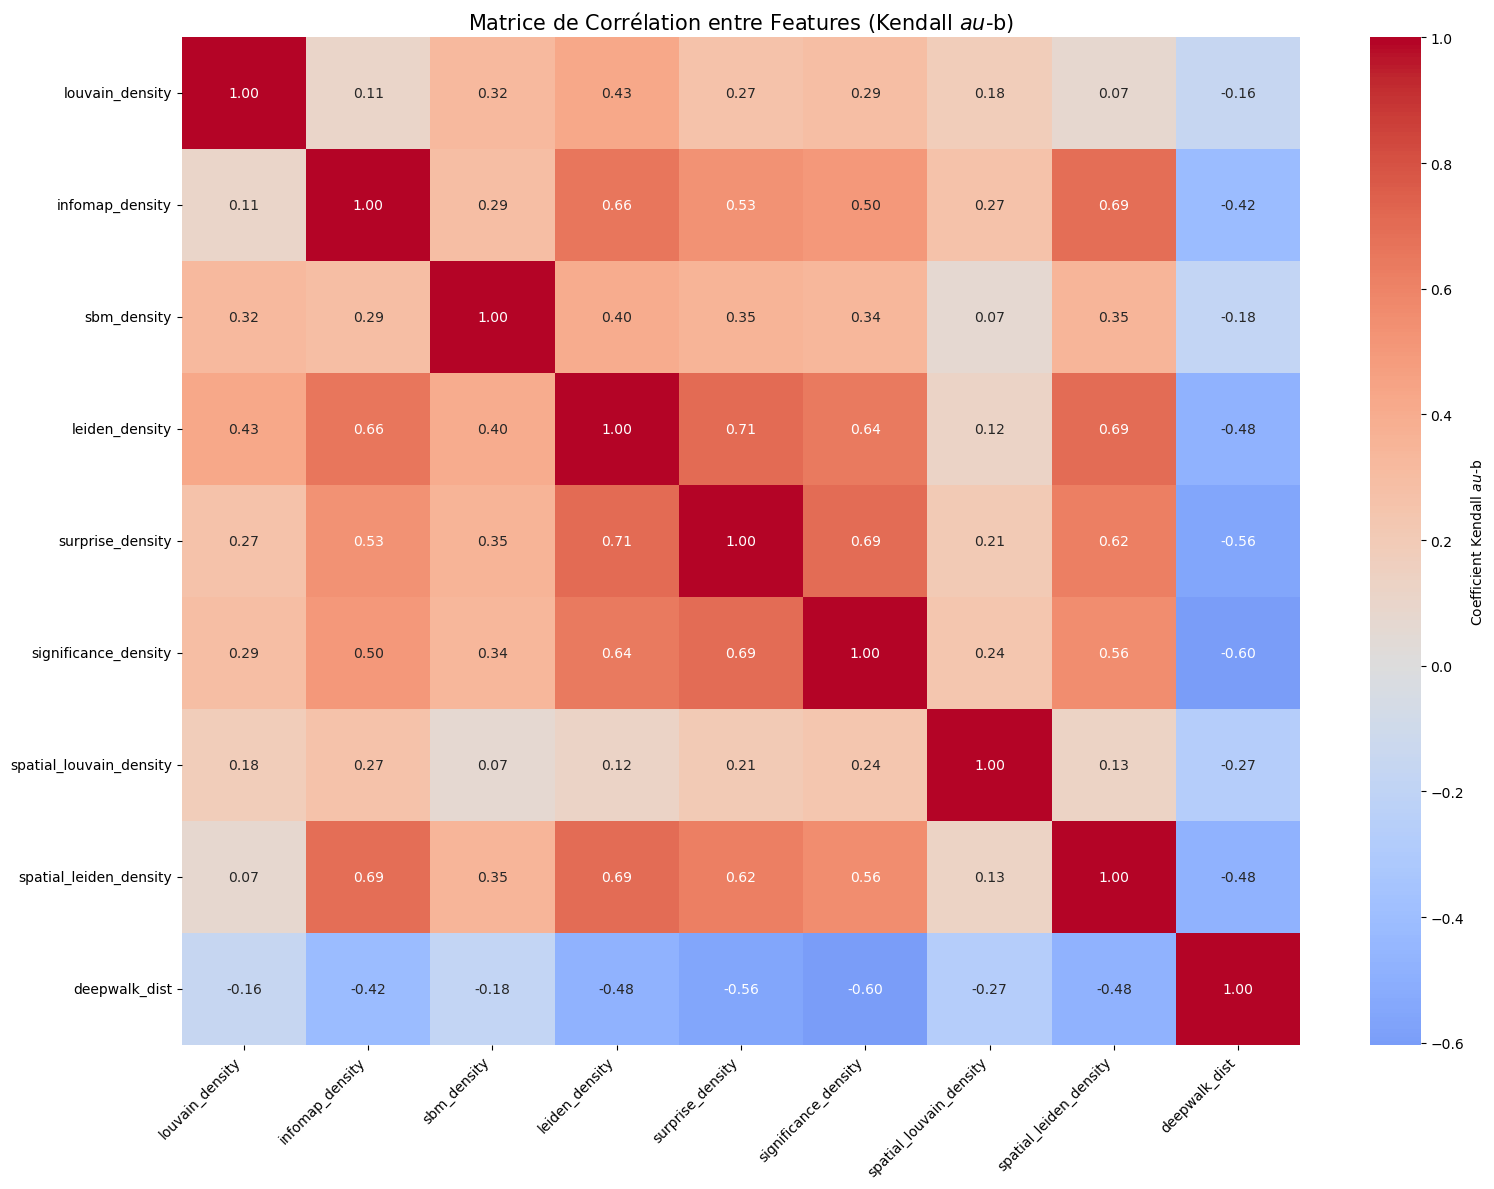

                         louvain_density  infomap_density  sbm_density  \
louvain_density                 1.000000         0.109383     0.318951   
infomap_density                 0.109383         1.000000     0.292402   
sbm_density                     0.318951         0.292402     1.000000   
leiden_density                  0.425807         0.659796     0.402855   
surprise_density                0.265606         0.532697     0.349590   
significance_density            0.292213         0.502481     0.336569   
spatial_louvain_density         0.184022         0.266841     0.066006   
spatial_leiden_density          0.073260         0.689122     0.346626   
deepwalk_dist                  -0.162942        -0.416099    -0.178445   

                         leiden_density  surprise_density  \
louvain_density                0.425807          0.265606   
infomap_density                0.659796          0.532697   
sbm_density                    0.402855          0.349590   
leiden_density 

In [35]:
from scipy import stats

feature_mapping = {
        "Groupe_Structure": ['pr_u', 'pr_v','ppr_u', 'ppr_v', 'lcc_u', 'lcc_v', 'and_u', 'and_v', 'dc_u', 'dc_v', 'katz_u', 'katz_v',
                              'sp', 'jc', 'aa', 'cn','pa', 'ra'],
        "Groupe_Communities": ['louvain_density', 'infomap_density', 'sbm_density', 'leiden_density', "surprise_density", "significance_density",
                               'same_louvain', 'same_infomap', 'same_sbm','same_leiden', "same_surprise", "same_significance"],
        "Groupe_Embeddings": ["deepwalk_cos", "n2v_homophily_cos", "crosswalk_cos",
                              "deepwalk_rank",  "n2v_homophily_rank", "crosswalk_rank", 
                              "deepwalk_had_mean", "n2v_homophily_had_mean", "crosswalk_had_mean",
                              "deepwalk_had_std",  "n2v_homophily_had_std","crosswalk_had_std", 
                              'deepwalk_dist','n2v_homophily_dist','crosswalk_dist'],
        "Groupe_stars": ['louvain_density', 'infomap_density', 'sbm_density', 'leiden_density', "surprise_density", "significance_density",
                         'spatial_louvain_density', 'spatial_leiden_density',
                         'deepwalk_dist']
}

for i in np.arange(1.00, 0.75, -0.25):
    sbm_val = f"{i:.2f}"
    pos_val = f"{1-i:.2f}"
    G_name = f"artificial_graph_sbmv4_{sbm_val.replace('.', '_')}_pos_{pos_val.replace('.', '_')}"

    G, dataset_train, _, _, _, _ = gp.load_all_data_for_graph(G_name)  
    #features = [c for c in dataset_train.columns if c != 'target']
    features = feature_mapping["Groupe_stars"]

    corr_matrix = dataset_train[features].corr(method="kendall")

    plt.figure(figsize=(16, 12))
    sns.heatmap(corr_matrix, annot=True, fmt=".2f",cmap='coolwarm',center=0,cbar_kws={'label': 'Coefficient Kendall $\tau$-b'})
    plt.title("Matrice de Corrélation entre Features (Kendall $\tau$-b)", fontsize=15)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    print (corr_matrix)

### 3.4 - Information mutuelle étude

In [192]:
from sklearn.feature_selection import mutual_info_regression

def compute_mi_matrix(df, features, categorical = True, normalized = False):
    n = len(features)
    mi_matrix = pd.DataFrame(np.zeros((n, n)), index=features, columns=features)
    
    for i in range(n):
        for j in range(i, n):
            f1, f2 = features[i], features[j]

            if categorical : 
                #val = normalized_mutual_info_score(df[f1], df[f2], average_method='arithmetic')
                val = adjusted_mutual_info_score(df[f1], df[f2])
            else : 
                val = mutual_info_regression(df[[f1]], df[f2])[0] # PB D'ID UNIK SI ON AJOUTE PRODUIT D DEGRES.

                if normalized : 
                    h_x = mutual_info_regression(df[[f1]], df[f1], random_state=42)[0]
                    h_y = mutual_info_regression(df[[f2]], df[f2], random_state=42)[0]
                    denom = min(h_x, h_y)
                
                    val = val / denom
                
            
            mi_matrix.loc[f1, f2] = val
            mi_matrix.loc[f2, f1] = val # Symetry, si i == j on écrase et c pa grav
            
    return mi_matrix

def get_unique_information(dataset, all_features, features_GT):
    # Calcul de I(X,GT|Autres) 
    unique_info_results = []
    
    series_GT = dataset[features_GT].astype(str).agg('-'.join, axis=1)
    series_ALL = dataset[all_features].astype(str).agg('-'.join, axis=1)
    mi_all_gt = mutual_info_score(series_ALL, series_GT)
    
    for feature in all_features:
        others = [f for f in all_features if f != feature]
        series_others = dataset[others].astype(str).agg('-'.join, axis=1)
        
        # I(Autres ; GT)
        mi_others_gt = mutual_info_score(series_others, series_GT)
        
        unique_info = max(0, mi_all_gt - mi_others_gt)
        unique_pct = (unique_info / mi_all_gt) * 100 if mi_all_gt > 0 else 0
        
        unique_info_results.append({
            "Feature": feature,
            "Unique Info (nats)": unique_info,
            "Contribution Unique (%)": unique_pct
        })
        
    return pd.DataFrame(unique_info_results).sort_values("Unique Info (nats)", ascending=False)

def bining_features_dataset(dataset, features, n_bins) :
    df_binned = dataset.copy()
    
    for col in features:
        # On binne chaque feature en quantiles (même nombre de points par bin)
        # On gère les duplicates au cas où une valeur (ex: 0) est ultra majoritaire
        try:
            df_binned[col] = pd.qcut(dataset_train[col], n_bins, labels=False, duplicates='drop')
        except Exception:
            # Si vraiment pas assez de valeurs distinctes pour faire des bins
            df_binned[col] = dataset_train[col]

    return df_binned


def get_joint_series(dataset, feature_list):
    """Combine plusieurs colonnes en une seule variable de partitions."""
    if not feature_list:
        return pd.Series(['0'] * len(dataset))
    return dataset[feature_list].astype(str).agg('-'.join, axis=1)

def get_entropy(series):
    p_data = series.value_counts(normalize=True)
    return entropy(p_data)

def get_cmi_score(dataset, X_features, Y_features, GT_features, divideByEntropyOfYknowingX = True):
    """
    Calcule l'Information Mutuelle Conditionnelle I(Y ; GT | X)
    Basée sur la règle de la chaîne : I(Y;GT|X) = I(X,Y;GT) - I(X;GT)
    """
    series_X = get_joint_series(dataset, X_features)
    series_XY = get_joint_series(dataset, X_features + Y_features)
    series_GT = get_joint_series(dataset, GT_features)
    
    i_xy_gt = mutual_info_score(series_XY, series_GT)
    i_x_gt = mutual_info_score(series_X, series_GT)
    cmi = max (0.0, i_xy_gt - i_x_gt)

    # Calcul de H(Y | X) = H(X, Y) - H(X)
    h_x = get_entropy(series_X)
    h_xy = get_entropy(series_XY)
    h_y_knowing_x = max(1e-9, h_xy - h_x) 

    if divideByEntropyOfYknowingX : 
        cmi = cmi / h_y_knowing_x
    
    return cmi

def get_coverage_ratio(dataset, feature_list, features_GT):
    """
    Calcule = I(Features ; GT) / H(GT)
    """
    series_X = dataset[feature_list].astype(str).agg('-'.join, axis=1)
    series_GT = dataset[features_GT].astype(str).agg('-'.join, axis=1)
    
    mi_score = mutual_info_score(series_X, series_GT)

    p_gt = series_GT.value_counts(normalize=True)
    h_gt = entropy(p_gt)
    coverage = (mi_score / h_gt)
    
    return min(1.0, coverage)

def get_nmi_for_group(df, feature_list, target_features):
    joint_X = df[feature_list].astype(str).agg('-'.join, axis=1)
    joint_Y = df[target_features].astype(str).agg('-'.join, axis=1)
  
    return adjusted_mutual_info_score(joint_X, joint_Y, average_method='min')


feature_mapping = {
        "Groupe_Structure": ['pr_u', 'pr_v','ppr_u', 'ppr_v', 'lcc_u', 'lcc_v', 'and_u', 'and_v', 'dc_u', 'dc_v', 'katz_u', 'katz_v',
                              'sp', 'jc', 'aa', 'cn','pa', 'ra'],
        "Groupe_Communities": ['louvain_density', 'infomap_density', 'sbm_density', 'leiden_density', "surprise_density", "significance_density",
                               #'same_louvain', 'same_infomap', 'same_sbm','same_leiden', "same_surprise", "same_significance"
                              ],
        "Groupe_Embeddings": ["deepwalk_cos", "n2v_homophily_cos", "crosswalk_cos",
                              "deepwalk_rank",  "n2v_homophily_rank", "crosswalk_rank", 
                              "deepwalk_had_mean", "n2v_homophily_had_mean", "crosswalk_had_mean",
                              "deepwalk_had_std",  "n2v_homophily_had_std","crosswalk_had_std", 
                              'deepwalk_dist','n2v_homophily_dist','crosswalk_dist'],
        "GT_sbm" : ['GT_sbm_density', 'GT_spatial_deg_product']
}

In [194]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn.metrics.cluster._supervised")

for i in np.arange(1.00, 0.75, -0.25):
    sbm_val = f"{i:.2f}"
    pos_val = f"{1-i:.2f}"
    G_name = f"artificial_graph_sbm4_{sbm_val.replace('.', '_')}_pos_{pos_val.replace('.', '_')}_GT"

    _, dataset_train, _, _, _, _ = gp.load_all_data_for_graph(G_name)

    features = feature_mapping["Groupe_Communities"] + feature_mapping["GT_sbm"]
    features_GT = feature_mapping["GT_sbm"]
    
    # Bining de toutes les features
    dataset_train = bining_features_dataset(dataset_train, features, 13)
    
    mi_matrix_categorical = compute_mi_matrix(dataset_train, features)
    mi_matrix_continuous = compute_mi_matrix(dataset_train, features, categorical=False, normalized=False)

    """
    plt.figure(figsize=(16, 12))
    sns.heatmap(mi_matrix_categorical, annot=True, fmt=".2f",cmap='coolwarm',center=0,cbar_kws={'label': 'Coefficient Kendall $\tau$-b'})
    plt.title("Matrice des Mutal Information entre paires des Features", fontsize=15)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    """

    current_best_features = ["surprise_density", "sbm_density", "significance_density"]
    all_features = ["infomap_density", "louvain_density", "leiden_density", "sbm_density", "surprise_density", "significance_density"]

    baseline_coverage_ratio = get_coverage_ratio(dataset_train, current_best_features, features_GT)
    best_coverage_ratio = get_coverage_ratio(dataset_train, all_features, features_GT)
    candidates = [f for f in all_features if f not in current_best_features]
    extension_results = []
    
    for candidate in candidates:
        #cmi_score_divided_by_hy_knowing_x = get_cmi_score(dataset_train, current_best_features, [candidate], features_GT)
        cmi_score = get_cmi_score(dataset_train, current_best_features, [candidate], features_GT, divideByEntropyOfYknowingX = False)

        coverage_ratio = get_coverage_ratio(dataset_train, current_best_features + [candidate], features_GT)
        
        extension_results.append({
            "Variable testée": candidate,
            "Cmi Score": cmi_score,
            "Coverage_ratio" : coverage_ratio,
            "Coverage_ratio/best_possible" : coverage_ratio/best_coverage_ratio
        })
    
    print(f"Score de base avec {current_best_features} : {baseline_coverage_ratio:.4f}\n, soit {baseline_coverage_ratio/best_coverage_ratio:.2f} du best possible, aka {best_coverage_ratio:.2f}")
    df_ext = pd.DataFrame(extension_results).sort_values("Cmi Score", ascending=False)
    print(df_ext)

    unique_info = get_unique_information(dataset_train, all_features, features_GT)
    print(unique_info)
    


SHAP Analysis introuvable pour artificial_graph_sbmv5_1_00_pos_0_00_GT.
Score de base avec ['surprise_density', 'sbm_density', 'significance_density'] : 0.3619
, soit 0.76 du best possible, aka 0.48
   Variable testée  Cmi Score  Coverage_ratio  Coverage_ratio/best_possible
2   leiden_density   0.434163        0.458842                      0.963437
1  louvain_density   0.235475        0.414461                      0.870249
0  infomap_density   0.200772        0.406709                      0.853973
                Feature  Unique Info (nats)  Contribution Unique (%)
5  significance_density            0.480216                22.522789
4      surprise_density            0.412733                19.357730
3           sbm_density            0.311750                14.621505
2        leiden_density            0.170063                 7.976200
0       infomap_density            0.077957                 3.656298
1       louvain_density            0.000000                 0.000000


### 3.5 - MI(X,GT)/H(X) entre features et GT

In [150]:
def calculate_entropy(labels):
    """Calcule l'entropie H(X) en bits."""
    prob_dist = pd.Series(labels).value_counts(normalize=True)
    return -(prob_dist * np.log2(prob_dist)).sum()

def get_adjusted_mi(feature, target):
    """Calcule l'AMI qui gère la normalisation par une comparaison et correction du hasard"""
    # L'AMI s'attend à des variables discrètes (int ou str)
    return adjusted_mutual_info_score(feature, target)

def get_normalized_mi(feature, target):
    """Calcule le ratio I(X; GT) / H(X)."""
    # mutual_info_score utilise le log naturel par défaut, on convertit en bits (log2)
    mi = mutual_info_score(feature, target) / np.log(2)
    h_x = calculate_entropy(feature)
    return mi / h_x if h_x > 1e-9 else 0

features_to_test = [#"leiden_density", "spatial_leiden_density",
                    #"spatial_leiden_scgravity_density",  "spatial_leiden_wrdb_density", 
                    "louvain_density", 
                    "spatial_louvain_density",
                    "spatial_louvain_manualreg_density",
                    "spatial_louvain_scgravity_density",
                    "spatial_louvain_wrdb_density"]

all_results = []

for nbiter in range (1,31): 
    for i in np.arange(1.00, -0.10, -0.10):
        sbm_val = f"{i:.2f}"
        pos_val = f"{1-i:.2f}"
        G_name = f"artificial_graph_sbmv4_{sbm_val.replace('.', '_')}_pos_{pos_val.replace('.', '_')}_{nbiter}"
    
        #_, dataset_train, _, _, _, _ = gp.load_all_data_for_graph(G_name)
        dataset_train = gp.load_dataset(filename=f"dataset_train_{G_name}", talk=False)
        if round(i, 2) == 0.50 :
            print(f"Dataset récupéré pour {G_name}")
        
        gt_sbm = dataset_train['GT_sbm_density'].round(5).astype(str)
        # Binning Logarithmique pour la distance
        bins_log = np.logspace(np.log10(dataset_train['GT_pos_dist'].min() + 1e-9), 
                               np.log10(dataset_train['GT_pos_dist'].max()), 
                               num=21)
        bins_log[0] = -np.inf 
        bins_log[-1] = np.inf #On évite les "hors bins"
        
        gt_pos = pd.cut(dataset_train['GT_pos_dist'], bins=bins_log, labels=False, include_lowest=True)
    
        for feat in features_to_test:
            #Pour éviter que la MI voit des valeurs différentes si écart minime de précision du float
            feat_vector = dataset_train[feat].round(5).astype(str)
            
            #mi_sbm_ratio = get_normalized_mi(feat_vector, gt_sbm)
            #mi_pos_ratio = get_normalized_mi(feat_vector, gt_pos)
            mi_sbm_ratio = get_adjusted_mi(feat_vector, gt_sbm)
            mi_pos_ratio = get_adjusted_mi(feat_vector, gt_pos)
            entropie_feature = calculate_entropy(feat_vector)
            
            all_results.append({
                'iter': nbiter,
                'ratio_sbm': i,
                'feature': feat,
                'mi_ratio_sbm': mi_sbm_ratio,
                'mi_ratio_pos': mi_pos_ratio,
                'entropie_feature': entropie_feature
            })

df_res = pd.DataFrame(all_results)

Dataset récupéré pour artificial_graph_sbmv4_0_50_pos_0_50_1
Dataset récupéré pour artificial_graph_sbmv4_0_50_pos_0_50_2
Dataset récupéré pour artificial_graph_sbmv4_0_50_pos_0_50_3
Dataset récupéré pour artificial_graph_sbmv4_0_50_pos_0_50_4
Dataset récupéré pour artificial_graph_sbmv4_0_50_pos_0_50_5
Dataset récupéré pour artificial_graph_sbmv4_0_50_pos_0_50_6
Dataset récupéré pour artificial_graph_sbmv4_0_50_pos_0_50_7
Dataset récupéré pour artificial_graph_sbmv4_0_50_pos_0_50_8
Dataset récupéré pour artificial_graph_sbmv4_0_50_pos_0_50_9
Dataset récupéré pour artificial_graph_sbmv4_0_50_pos_0_50_10
Dataset récupéré pour artificial_graph_sbmv4_0_50_pos_0_50_11
Dataset récupéré pour artificial_graph_sbmv4_0_50_pos_0_50_12
Dataset récupéré pour artificial_graph_sbmv4_0_50_pos_0_50_13
Dataset récupéré pour artificial_graph_sbmv4_0_50_pos_0_50_14
Dataset récupéré pour artificial_graph_sbmv4_0_50_pos_0_50_15
Dataset récupéré pour artificial_graph_sbmv4_0_50_pos_0_50_16
Dataset récupéré 

Graphique sauvegardé dans : outputs/plots/MI_X_GT_by_H_X_smbv4_30iter_GT_pos_inferences_louvain.png


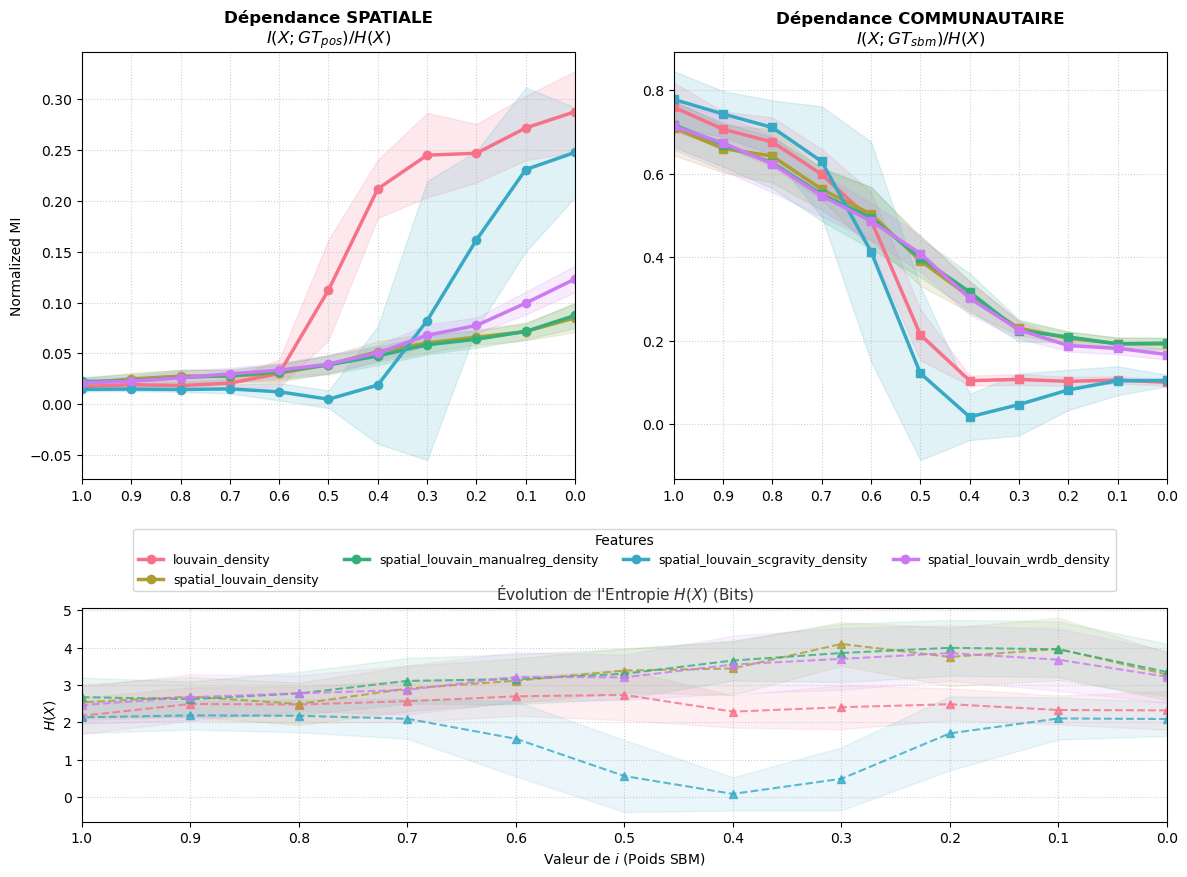

In [149]:
stats = df_res.groupby(['feature', 'ratio_sbm']).agg({
    'mi_ratio_pos': ['mean', 'std'],
    'mi_ratio_sbm': ['mean', 'std'],
    'entropie_feature': ['mean', 'std']
}).reset_index()

# On aplatit les colonnes multi-index pour faciliter l'accès
stats.columns = ['feature', 'ratio_sbm', 
                 'mi_ratio_pos_mean', 'mi_ratio_pos_std', 
                 'mi_ratio_sbm_mean', 'mi_ratio_sbm_std', 
                 'entropie_mean', 'entropie_std']

features = stats['feature'].unique()
i_values = sorted(stats['ratio_sbm'].unique(), reverse=True)
colors = sns.color_palette("husl", len(features))

fig = plt.figure(figsize=(14, 10))
gs = gridspec.GridSpec(2, 2, height_ratios=[2, 1])

ax1 = fig.add_subplot(gs[0, 0]) # MI Pos (Haut Gauche)
ax2 = fig.add_subplot(gs[0, 1]) # MI SBM (Haut Droite)
ax3 = fig.add_subplot(gs[1, :]) # Entropie (Bas, toute la largeur)

# 3. Plotting
for feat, color in zip(features, colors):
    subset = stats[stats['feature'] == feat]
    ax1.plot(subset['ratio_sbm'], subset['mi_ratio_pos_mean'], label=feat, marker='o', color=color, linewidth=2.5)
    ax1.fill_between(subset['ratio_sbm'], subset['mi_ratio_pos_mean'] - subset['mi_ratio_pos_std'], subset['mi_ratio_pos_mean'] + subset['mi_ratio_pos_std'], color=color, alpha=0.15)
    ax2.plot(subset['ratio_sbm'], subset['mi_ratio_sbm_mean'], label=feat, marker='s', color=color, linewidth=2.5)
    ax2.fill_between(subset['ratio_sbm'], subset['mi_ratio_sbm_mean'] - subset['mi_ratio_sbm_std'], subset['mi_ratio_sbm_mean'] + subset['mi_ratio_sbm_std'], color=color, alpha=0.15)
    ax3.plot(subset['ratio_sbm'], subset['entropie_mean'], label=feat, marker='^', linestyle='--', color=color, alpha=0.8)
    ax3.fill_between(subset['ratio_sbm'], subset['entropie_mean'] - subset['entropie_std'], subset['entropie_mean'] + subset['entropie_std'], color=color, alpha=0.1)

# --- Formatage AX1 & AX2 ---
ax1.set_title("Dépendance SPATIALE\n$I(X; GT_{pos}) / H(X)$", fontsize=12, fontweight='bold')
ax2.set_title("Dépendance COMMUNAUTAIRE\n$I(X; GT_{sbm}) / H(X)$", fontsize=12, fontweight='bold')
ax1.set_ylabel("Normalized MI")

# --- Formatage AX3 ---
ax3.set_title("Évolution de l'Entropie $H(X)$ (Bits)", fontsize=11, alpha=0.8)
ax3.set_xlabel("Valeur de $i$ (Poids SBM)")
ax3.set_ylabel("$H(X)$")

# Configuration commune des axes
for ax in [ax1, ax2, ax3]:
    ax.set_xticks(i_values)
    ax.set_xticklabels([f"{v:.1f}" for v in i_values])
    ax.set_xlim(max(i_values), min(i_values))
    ax.grid(True, linestyle=':', alpha=0.6)

# --- Positionnement de la légende ---
ax1.legend(loc='upper center', bbox_to_anchor=(1.1, -0.1), ncol=4, fontsize=9, frameon=True, title="Features")

plt.subplots_adjust(hspace=0.4, wspace=0.2)

output_path = "outputs/plots"
#save_name = os.path.join(output_path, "MI_X_GT_by_H_X_smbv4_30iter_GT_pos_inferences_louvain.png")
save_name = os.path.join(output_path, "MI_adjusted_X_GT_smbv4_30iter_GT_pos_inferences_louvain.png")
plt.savefig(save_name, dpi=300, bbox_inches='tight')
print(f"Graphique sauvegardé dans : {save_name}")

plt.show()

## 4 - Other

In [68]:
sbm_val = "1_00"
pos_val = "0_00"
G_name = f"artificial_graph_sbmv4_{sbm_val}_pos_{pos_val}"

G_train, dataset_train, _, _, _, _ = gp.load_all_data_for_graph(G_name)

if 'GroundTruth_JSON' in G_train.graph:
    print(f"[INIT] Extraction de la GT GroundTruth pour {G_name}...")
    gt_raw = json.loads(G_train.graph['GroundTruth_JSON'])
    
    GT = {'GT_pos': np.array(gt_raw['GT_pos'])}

if GT is not None and 'GT_pos' in GT:
    for i, node_id in enumerate(G_train.nodes()):
        G_train.nodes[node_id]['GT_pos'] = GT['GT_pos'][i]

P, node = gput.get_radiation_null_model_iterative(G_train, "GT_pos", speak=True)

#G_train= gput._appendSpatialLouvainCommunities(G_train)
#G_train= gput._appendSpatialLeidenCommunities(G_train)

P_symetrik = (P+P.T)/2

print(np.sum(P - P_symetrik) / np.sum(P))

SHAP Analysis introuvable pour artificial_graph_sbmv4_1_00_pos_0_00.
[INIT] Extraction de la GT GroundTruth pour artificial_graph_sbmv4_1_00_pos_0_00...
Lancement de l'optimisation L-BFGS-B pour 198 noeuds...


KeyboardInterrupt: 